<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_EQ_3_Conteo_Vegetacion_ProyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌱 Conteo de Vegetación con IA — Proyecto Final Módulo 6

**Dr. Francisco J. Rodríguez**

Integrantes del equipo:
- Héctor Hugo Domínguez Jaime
- Sergio Raúl Bonilla Alejo
- César Geovanni Machuca Pereida

---

Proyecto final del Módulo 6: pipeline de visión por computadora para contar plantas en parcelas agrícolas a partir de fotos de dron o celular. El objetivo del sistema es estimar la densidad de vegetación (especialmente en etapas de emergencia, donde las plantas son pequeñas y dispersas), primero con procesamiento clásico de color y, en fases posteriores, con un modelo entrenado.

Este README está escrito para que una IA o una persona pueda entender el proyecto y continuar el trabajo sin re-descubrir nada. Léelo completo antes de modificar código.

El pipeline completo tiene 4 fases:

```
Fase 1 (hecha)        Fase 2 (hecha)              Fase 2–3 (proceso)          Fase 3 (proceso)
Fotos de dron     ->  Cortar en tiles          ->  Dataset YOLO (por vuelo) -> Conteo con el modelo
conteo clásico        descartar tiles vacíos       entrenar YOLO26 + val     entrenado (infer.py)
por color             generar manifest.csv         mAP
```

| Fase | Script / archivo | Qué hace |
|---|---|---|
| 1 | `conteo_vegetacion.html` | Prototipo 100% navegador: conteo clásico por color (Excess Green Index) + componentes conexas |
| 2 | `tile_pipeline.py` | Corta fotos grandes en *tiles* etiquetables y descarta tiles de suelo vacío |
| 2–3 | `convert_polygon_to_bbox.py` | Convierte etiquetas de polígono (Roboflow) a cajas YOLO |
| 2–3 | `prepare_dataset.py` | Arma el dataset YOLO (split train/valid por vuelo + `data.yaml`) |
| 2–3 | `train.py` | Entrena un modelo YOLO26 sobre el dataset y reporta mAP |
| 3 | `infer.py` | Cuenta plantas en fotos nuevas con el modelo entrenado (dedup por IoU global) |


## Cómo usar este notebook

1. Ejecuta las celdas en orden, de arriba hacia abajo.
2. Las fases 1 y 2 corren siempre (son rápidas y no requieren GPU ni internet, salvo por Google Fonts en la fase 1).
3. Las fases 2–3 (dataset) y 3 (entrenamiento/inferencia) usan datos **sintéticos de ejemplo** (una imagen de muestra y etiquetas ficticias) solo para mostrar que el pipeline corre correctamente extremo a extremo. **Para un proyecto real** debes sustituir la carpeta de fotos de dron, etiquetar en Roboflow/CVAT y volver a correr desde la Fase 2.
4. El entrenamiento (`train.py`) está desactivado por defecto (`RUN_TRAINING = False`) porque instala `ultralytics`/`torch` (pesado) y tarda varios minutos incluso en modo demo. Cámbialo a `True` si quieres verlo correr.


## 0. Preparación del entorno

Instalamos las dependencias ligeras (`Pillow`, `numpy`, `PyYAML`) y creamos la carpeta de trabajo del proyecto.

In [ ]:
import importlib.util, subprocess, sys

def _ensure(pkg_import, pip_spec):
    if importlib.util.find_spec(pkg_import) is not None:
        return
    for extra in ([], ["--user"], ["--break-system-packages"]):
        try:
            subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q", pip_spec, *extra],
                check=True,
            )
            return
        except subprocess.CalledProcessError:
            continue
    print(f"No se pudo instalar {pip_spec} automaticamente; instalalo manualmente si algo falla mas abajo.")

_ensure("PIL", "Pillow>=10.0")
_ensure("numpy", "numpy>=1.26")
_ensure("yaml", "PyYAML==6.0.3")
print("Dependencias base listas.")

Dependencias base listas.


In [ ]:
import os
from pathlib import Path

PROJECT_DIR = Path("conteo_vegetacion_proyecto")
PROJECT_DIR.mkdir(exist_ok=True)
os.chdir(PROJECT_DIR)
print("Directorio de trabajo:", Path.cwd())

Directorio de trabajo: /content/conteo_vegetacion_proyecto


### Recreando los scripts originales del proyecto

Las siguientes celdas usan la magia `%%writefile` de Jupyter para escribir, tal cual, cada archivo del repositorio (`tile_pipeline.py`, `convert_polygon_to_bbox.py`, `prepare_dataset.py`, `train.py`, `infer.py`, `conteo_vegetacion.html`). No necesitas tocarlas.

In [ ]:
%%writefile tile_pipeline.py
#!/usr/bin/env python3
"""
tile_pipeline.py
=================

Fase 2 - Preparacion de imagenes para etiquetado.

Corta fotos de dron (grandes, con plantas pequenas) en tiles (recortes)
mas pequenos, para que cada planta ocupe suficientes pixeles y sea facil
de etiquetar en Roboflow/CVAT. Tambien descarta automaticamente tiles
"vacios" (puro suelo uniforme, sin nada que etiquetar) para no perder
tiempo etiquetando recortes sin contenido util.

Estructura de entrada esperada (la misma que sugiere el checklist de campo):

    input_dir/
        ParcelaA_2026-09-10_emergencia/
            DJI_0001.JPG
            DJI_0002.JPG
            ...
        ParcelaB_2026-09-12_emergencia/
            DJI_0001.JPG
            ...

Cada subcarpeta = un vuelo (una parcela, una fecha, una etapa).

Salida generada:

    output_dir/
        ParcelaA_2026-09-10_emergencia/
            DJI_0001_x00000_y00000.jpg
            DJI_0001_x00544_y00000.jpg
            ...
        ParcelaB_2026-09-12_emergencia/
            ...
        manifest.csv   <- registro de cada tile: imagen origen, posicion, tamano

El manifest.csv es importante: mas adelante permite (a) saber de que foto
original vino cada tile, y (b) si se etiqueta a nivel de tile, reconstruir
o auditar el conteo total por foto o por parcela.

Uso basico:
    python3 tile_pipeline.py --input ./fotos_dron --output ./tiles

Uso con parametros ajustados:
    python3 tile_pipeline.py --input ./fotos_dron --output ./tiles \
        --tile-size 768 --overlap 0.15 --min-pixels 150

Requisitos:
    pip install pillow numpy --break-system-packages
"""

import argparse
import csv
import sys
from pathlib import Path

from PIL import Image
import numpy as np

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}


def find_flight_folders(input_dir: Path):
    """Cada subcarpeta directa de input_dir se trata como un vuelo (parcela+fecha+etapa).
    Si el usuario apunta directo a una carpeta con fotos sueltas (sin subcarpetas),
    esa carpeta se trata como un unico 'vuelo'."""
    subfolders = [f for f in input_dir.iterdir() if f.is_dir()]
    if subfolders:
        return sorted(subfolders)
    return [input_dir]


def list_images(folder: Path):
    return sorted(
        [f for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS]
    )


def tile_positions(width, height, tile_size, overlap):
    """Genera las coordenadas (x, y) de la esquina superior-izquierda de cada tile,
    cubriendo toda la imagen con el traslape indicado. El ultimo tile de cada fila/
    columna se ajusta hacia adentro para no salirse del borde de la imagen."""
    stride = max(1, int(tile_size * (1 - overlap)))

    xs = list(range(0, max(width - tile_size, 0) + 1, stride))
    ys = list(range(0, max(height - tile_size, 0) + 1, stride))

    # Asegurar cobertura del borde derecho / inferior si la imagen no es multiplo exacto
    if not xs or xs[-1] + tile_size < width:
        xs.append(max(width - tile_size, 0))
    if not ys or ys[-1] + tile_size < height:
        ys.append(max(height - tile_size, 0))

    # Quitar duplicados manteniendo orden
    xs = sorted(set(xs))
    ys = sorted(set(ys))
    return [(x, y) for y in ys for x in xs]


def has_enough_detail(tile_img: Image.Image, min_pixels: int, color_diff: float = 25.0) -> bool:
    """Descarta tiles casi uniformes (ej. franjas de suelo desnudo sin nada que
    etiquetar), sin penalizar tiles con plantas pequenas y dispersas (comun en
    etapas de emergencia). En vez de medir la variacion total del tile -que es
    baja cuando las plantas cubren poca area aunque esten presentes-, cuenta
    cuantos pixeles se distinguen claramente del color de fondo dominante.
    min_pixels mas alto = mas estricto (descarta mas tiles casi vacios)."""
    arr = np.asarray(tile_img.convert("RGB"), dtype=np.int16)
    flat = arr.reshape(-1, 3)
    background = np.median(flat, axis=0)
    diff = np.abs(arr - background).sum(axis=2)
    foreground_pixels = int((diff > color_diff).sum())
    return foreground_pixels >= min_pixels


def process_flight_folder(folder: Path, out_root: Path, tile_size: int,
                           overlap: float, min_pixels: int, manifest_rows: list):
    images = list_images(folder)
    if not images:
        print(f"  (sin imagenes en {folder.name}, se omite)")
        return

    out_folder = out_root / folder.name
    out_folder.mkdir(parents=True, exist_ok=True)

    kept, skipped = 0, 0
    for img_path in images:
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"  ! No se pudo abrir {img_path.name}: {e}")
            continue

        w, h = img.size
        if w < tile_size or h < tile_size:
            print(f"  ! {img_path.name} es mas pequena que el tile ({w}x{h}), se copia entera")
            positions = [(0, 0)]
            effective_tile_w, effective_tile_h = w, h
        else:
            positions = tile_positions(w, h, tile_size, overlap)
            effective_tile_w, effective_tile_h = tile_size, tile_size

        for (x, y) in positions:
            box = (x, y, min(x + effective_tile_w, w), min(y + effective_tile_h, h))
            tile = img.crop(box)

            if not has_enough_detail(tile, min_pixels):
                skipped += 1
                continue

            tile_name = f"{img_path.stem}_x{x:05d}_y{y:05d}.jpg"
            tile.save(out_folder / tile_name, quality=95)

            manifest_rows.append({
                "vuelo": folder.name,
                "imagen_origen": img_path.name,
                "tile": tile_name,
                "x_offset": x,
                "y_offset": y,
                "tile_w": box[2] - box[0],
                "tile_h": box[3] - box[1],
                "imagen_ancho": w,
                "imagen_alto": h,
            })
            kept += 1

    print(f"  {folder.name}: {kept} tiles guardados, {skipped} descartados por parecer suelo vacio")


def main():
    parser = argparse.ArgumentParser(description="Recorta fotos de dron en tiles para etiquetado.")
    parser.add_argument("--input", required=True, help="Carpeta con las fotos originales (o subcarpetas por vuelo)")
    parser.add_argument("--output", required=True, help="Carpeta donde se guardan los tiles")
    parser.add_argument("--tile-size", type=int, default=640, help="Tamano del tile en pixeles (default: 640)")
    parser.add_argument("--overlap", type=float, default=0.15, help="Traslape entre tiles, 0-0.5 (default: 0.15)")
    parser.add_argument("--min-pixels", type=int, default=150,
                         help="Minimo de pixeles distintos al fondo para conservar un tile (default: 150). "
                              "Sube este valor si quedan tiles de puro suelo vacio; bajalo si se estan "
                              "perdiendo tiles con plantas pequenas y muy dispersas (etapa de emergencia).")
    args = parser.parse_args()

    input_dir = Path(args.input)
    output_dir = Path(args.output)

    if not input_dir.exists():
        print(f"Error: no existe la carpeta de entrada {input_dir}", file=sys.stderr)
        sys.exit(1)

    output_dir.mkdir(parents=True, exist_ok=True)

    flights = find_flight_folders(input_dir)
    print(f"Vuelos/carpetas encontrados: {len(flights)}")

    manifest_rows = []
    for folder in flights:
        process_flight_folder(folder, output_dir, args.tile_size, args.overlap,
                               args.min_pixels, manifest_rows)

    manifest_path = output_dir / "manifest.csv"
    if manifest_rows:
        with open(manifest_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(manifest_rows[0].keys()))
            writer.writeheader()
            writer.writerows(manifest_rows)
        print(f"\nListo. {len(manifest_rows)} tiles generados en total.")
        print(f"Manifest guardado en: {manifest_path}")
        print("\nSiguiente paso: sube la carpeta de tiles (por vuelo) a Roboflow o CVAT para etiquetar.")
    else:
        print("\nNo se genero ningun tile. Revisa la carpeta de entrada y el umbral --min-pixels.")


if __name__ == "__main__":
    main()


Writing tile_pipeline.py


In [ ]:
%%writefile convert_polygon_to_bbox.py
#!/usr/bin/env python3
"""
convert_polygon_to_bbox.py
==========================

Convierte etiquetas YOLO en formato POLIGONO (clase x1 y1 x2 y2 ...) al
formato CAJA que consume el pipeline (clase cx cy w h, 5 campos), y reconstruye
el nombre original del tile desde el renombrado que aplica Roboflow al exportar.

Uso tipico (tras exportar desde Roboflow en formato yolov8):

    python3 convert_polygon_to_bbox.py \
        --export datasets/roboflow_export/train \
        --output datasets/labels_src/fotos_dron

Entrada esperada (--export):

    train/
      images/<tile>_jpg.rf.<hash>.jpg      <- nombre Roboflow, un tile por imagen
      labels/<tile>_jpg.rf.<hash>.txt      <- poligonos YOLO: 0 x1 y1 x2 y2 ...

Salida (--output): el directorio de vuelo que consume prepare_dataset.py
(--labels), escribiendo por cada tile:

    <tile>.jpg                             <- imagen con el nombre original del tile
    <tile>.txt                             <- caja YOLO: 0 cx cy w h (bbox del poligono)

El formato de extension se conserva tal cual viene del export (jpg/jpeg/png),
y el marcador de Roboflow se detecta por la extension real del archivo. La
conversion es validate-then-write: si CUALQUIER label esta malformado, el
script falla con mensaje contextual y no escribe nada (misma filosofia
fail-fast que prepare_dataset.py).

Por que existe: Roboflow permite anotar con poligonos y su export 'yolov8'
los conserva como poligonos, pero prepare_dataset.py e infer.py exigen cajas
(class x y w h normalizadas). Este script cierra esa brecha convirtiendo cada
poligono a su bounding box (min/max de x e y).
"""

import argparse
import shutil
import sys
from pathlib import Path
from typing import Iterable

# Extensiones de imagen aceptadas en el export de Roboflow (misma familia que
# IMAGE_EXTENSIONS de tile_pipeline.py).
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# Precision de los floats normalizados que se escriben en los sidecars. Fija
# en 8 decimales: suficiente para coordenadas YOLO normalizadas (~0.4 px en un
# tile de 640x640) y mantiene el contrato de exactamente 5 campos por linea.
BBOX_PRECISION = 8


class LabelFormatError(ValueError):
    """Label malformado: el script falla con contexto y no escribe nada."""


def roboflow_stem_to_tile(name: str) -> str:
    """Restaura el nombre original del tile desde el nombre Roboflow.

    Roboflow reescribe el stem como "<tile>_<ext>.rf.<hash>.<ext>". Se quita la
    extension y luego el marcador "_<ext>.rf.", detectado por la extension real
    del archivo (jpg/jpeg/png).
    """
    stem = name
    suffix = Path(name).suffix.lower()
    if suffix in IMAGE_EXTENSIONS:
        stem = stem[: -len(suffix)]
    marker = f"_{suffix.lstrip('.')}.rf."
    if marker in stem:
        stem = stem.split(marker, 1)[0]
    return stem


def polygon_to_bbox(class_id: str, points: list[str]) -> str:
    """Convierte un poligono YOLO (class x1 y1 x2 y2 ...) a su bounding box.

    El poligono debe tener un numero PAR de coordenadas (pares x,y). Con
    coordenadas impares se lanza LabelFormatError: la ultima x quedaria sin su
    y y el rango vertical se colapsaria en silencio (corrupcion silenciosa).
    """
    if len(points) % 2 != 0:
        raise LabelFormatError(
            f"poligono con {len(points)} coordenadas (debe ser par): {class_id} {' '.join(points)}"
        )
    try:
        coords = [float(v) for v in points]
    except ValueError as exc:
        raise LabelFormatError(
            f"coordenada no numerica: {exc} (linea: {class_id} {' '.join(points)})"
        ) from None
    xs, ys = coords[0::2], coords[1::2]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2
    w = x_max - x_min
    h = y_max - y_min
    if w == 0 and h == 0:
        raise LabelFormatError(
            f"poligono degenerado (area cero): {class_id} {' '.join(points)}"
        )
    return f"{class_id} {cx:.{BBOX_PRECISION}f} {cy:.{BBOX_PRECISION}f} {w:.{BBOX_PRECISION}f} {h:.{BBOX_PRECISION}f}"


def parse_label(txt_path: Path) -> list[str]:
    """Parsea un sidecar de poligonos a cajas SIN escribir nada.

    Lineas vacias se ignoran; una linea malformada aborta con contexto de
    archivo:linea. Devuelve las lineas bbox ya formateadas. Separado de
    convert_label para poder validar TODO el export antes de escribir nada
    (validate-then-write).
    """
    lines = txt_path.read_text(encoding="utf-8").splitlines()
    bboxes = []
    for lineno, line in enumerate(lines, start=1):
        if not line.strip():
            continue
        fields = line.split()
        try:
            bboxes.append(polygon_to_bbox(fields[0], fields[1:]))
        except LabelFormatError as exc:
            raise LabelFormatError(
                f"malformed label {txt_path}:{lineno}: {exc}"
            ) from None
    return bboxes


def convert_label(txt_path: Path, out_txt: Path) -> int:
    """Parsea y escribe un sidecar ya validado; devuelve la cantidad de cajas."""
    bboxes = parse_label(txt_path)
    out_txt.write_text("\n".join(bboxes) + ("\n" if bboxes else ""), encoding="utf-8")
    return len(bboxes)


def collect_tiles(export: Path) -> list[Path]:
    """Lista las imagenes del export Roboflow, fallando si no hay ninguna.

    Una ruta mal escrita (--export sin images/) no debe reportar "0 tiles"
    como exito: eso esconderia el error hasta la fase siguiente.
    """
    images = sorted(
        p for ext in IMAGE_EXTENSIONS for p in (export / "images").glob(f"*{ext}")
    )
    if not images:
        raise LabelFormatError(
            f"no se encontraron imagenes en {export / 'images'} "
            f"(extensiones {sorted(IMAGE_EXTENSIONS)})"
        )
    return images


def main(argv: list[str] | None = None) -> int:
    parser = argparse.ArgumentParser(
        description="Convierte poligonos YOLO de Roboflow a cajas YOLO y restaura nombres de tile."
    )
    parser.add_argument("--export", required=True, help="carpeta train/ del export Roboflow (con images/ y labels/)")
    parser.add_argument("--output", required=True, help="directorio de vuelo de salida (el --labels de prepare_dataset.py)")
    args = parser.parse_args(argv)

    export = Path(args.export)
    out = Path(args.output)
    out.mkdir(parents=True, exist_ok=True)

    try:
        images = collect_tiles(export)
    except LabelFormatError as exc:
        print(f"error: {exc}", file=sys.stderr)
        return 1

    # Fase 1 - validar TODO antes de escribir nada (validate-then-write).
    # Se parsean los sidecars pero NO se escribe; recien en fase 2, cuando
    # todo el export es valido, se copian imagenes y sidecars. Un label
    # malformado aborta con mensaje contextual y exit 1, sin escribir nada.
    parsed: dict[Path, list[str] | None] = {}
    try:
        for img in images:
            tile_stem = roboflow_stem_to_tile(img.name)
            src_txt = export / "labels" / (img.stem + ".txt")
            if src_txt.exists():
                parsed[img] = parse_label(src_txt)
            else:
                parsed[img] = None  # tile de fondo sin etiqueta
    except LabelFormatError as exc:
        print(f"error: {exc}", file=sys.stderr)
        return 1

    # Fase 2 - escribir (recien aca se copian imagenes y sidecars).
    total_boxes = 0
    for img, bboxes in parsed.items():
        tile_stem = roboflow_stem_to_tile(img.name)
        suffix = img.suffix.lower()
        shutil.copyfile(img, out / f"{tile_stem}{suffix}")
        if bboxes is not None:
            out_txt = out / f"{tile_stem}.txt"
            out_txt.write_text("\n".join(bboxes) + ("\n" if bboxes else ""), encoding="utf-8")
            total_boxes += len(bboxes)
            print(f"{tile_stem}: {len(bboxes)} cajas")
        else:
            print(f"{tile_stem}: sin etiqueta (tile de fondo)")

    print(f"\nListo. {len(images)} tiles, {total_boxes} cajas en total -> {out}")
    return 0


if __name__ == "__main__":
    sys.exit(main())

Writing convert_polygon_to_bbox.py


In [ ]:
%%writefile prepare_dataset.py
#!/usr/bin/env python3
"""prepare_dataset.py — build a YOLO dataset from tile_pipeline.py output.

Reads tile_pipeline.py's manifest.csv plus the per-flight tile folders and
YOLO label sidecars, and writes a standard dataset layout:

    <output>/
        images/{train,valid}/   tile images (copied, never modified)
        labels/{train,valid}/   YOLO .txt sidecars (only for labeled tiles)
        data.yaml               deterministic YAML pointing at the layout

Flights are split independently (train/valid, default 80/20, fixed seed) so
tiles never leak across flights (FR-2). A tile without a label sidecar becomes
a background sample: its image goes to images/ only, never to labels/ (FR-3).

The pipeline validates ALL inputs (manifest, image files, sidecar contents)
before creating --output; on any error nothing is written (FR-4).
"""

import argparse
import csv
import random
import shutil
import sys
from pathlib import Path

import yaml

DEFAULT_VALID_RATIO = 0.2
DEFAULT_SEED = 42
DEFAULT_NAMES = ["plant"]
YOLO_LINE_FIELDS = 5


class DatasetError(Exception):
    """User-facing error: invalid input or inconsistent dataset layout."""


class LabelFormatError(ValueError):
    """A label sidecar failed the YOLO 5-field-per-line parse (C-3)."""


def group_flights(rows: list[dict]) -> dict[str, list[dict]]:
    """Group manifest rows by flight (the vuelo column), preserving manifest order.

    FR-1: each manifest row is assigned to exactly one flight group.
    """
    groups: dict[str, list[dict]] = {}
    for row in rows:
        groups.setdefault(row["vuelo"], []).append(row)
    return groups


def split_tiles(
    tiles: list[str],
    valid_ratio: float = DEFAULT_VALID_RATIO,
    seed: int = DEFAULT_SEED,
) -> tuple[list[str], list[str]]:
    """Split one flight's tiles into (train, valid) deterministically.

    FR-2: per-flight split, fixed seed (NFR-1). n == 1 → valid is empty and
    the tile goes to train; otherwise valid = clamp(round(valid_ratio * n),
    1, n - 1). The input order never matters: the tile names are sorted and a
    seeded Random drives the shuffle, so identical inputs + seed always
    produce identical sets.
    """
    n = len(tiles)
    if n == 1:
        return list(tiles), []
    valid_count = max(1, min(n - 1, round(valid_ratio * n)))
    ordered = sorted(tiles)
    rng = random.Random(seed)
    rng.shuffle(ordered)
    return ordered[valid_count:], ordered[:valid_count]


def build_yaml(dataset_path: Path, names: list[str] | None = None) -> dict:
    """Return the data.yaml dict for a dataset layout (FR-3).

    Key order is fixed (path, train, val, names) so the CLI can emit it with
    yaml.safe_dump(sort_keys=False) and produce byte-identical files across
    runs (NFR-1).
    """
    return {
        "path": str(dataset_path),
        "train": "images/train",
        "val": "images/valid",
        "names": list(names if names is not None else DEFAULT_NAMES),
    }


def validate_label_file(sidecar: Path) -> None:
    """Validate a YOLO sidecar before it is copied (C-3).

    Contract: one box per line as `class x y w h` (normalized floats), so
    every non-empty line must have exactly 5 whitespace-separated fields, a
    non-negative integer class id, and 4 float coordinates. Raises
    LabelFormatError on malformed content — fail fast, never ship a silently
    corrupted dataset.
    """
    try:
        lines = sidecar.read_text(encoding="utf-8").splitlines()
    except OSError as exc:
        raise LabelFormatError(f"cannot read label file {sidecar}: {exc}") from exc

    for lineno, line in enumerate(lines, start=1):
        if not line.strip():
            continue
        fields = line.split()
        if len(fields) != YOLO_LINE_FIELDS:
            raise LabelFormatError(
                f"malformed label {sidecar}:{lineno}: expected {YOLO_LINE_FIELDS} "
                f"fields (class x y w h), got {len(fields)}"
            )
        if not fields[0].isdigit():
            raise LabelFormatError(
                f"malformed label {sidecar}:{lineno}: class id {fields[0]!r} "
                f"is not a non-negative integer"
            )
        for field in fields[1:]:
            try:
                float(field)
            except ValueError:
                raise LabelFormatError(
                    f"malformed label {sidecar}:{lineno}: {field!r} is not a float"
                ) from None


def copy_label(src_txt: Path, dst_dir: Path) -> Path | None:
    """Copy a YOLO sidecar into dst_dir (FR-3).

    This is the single seam that reads label bytes (design D-3). Returns the
    destination path, or None when src_txt is missing — the tile is then a
    background sample and only its image is written. Malformed sidecars raise
    LabelFormatError so a corrupt dataset never ships silently.
    """
    if not src_txt.exists():
        return None
    validate_label_file(src_txt)
    dst = dst_dir / src_txt.name
    shutil.copyfile(src_txt, dst)
    return dst


def read_manifest(manifest_path: Path) -> list[dict]:
    """Parse manifest.csv into row dicts, validating its shape (FR-1).

    The file must exist, contain at least one data row, and provide the
    vuelo and tile columns. Raises DatasetError on any violation.
    """
    if not manifest_path.is_file():
        raise DatasetError(f"manifest not found: {manifest_path}")
    try:
        with manifest_path.open(newline="", encoding="utf-8") as fh:
            rows = list(csv.DictReader(fh))
    except OSError as exc:
        raise DatasetError(f"cannot read manifest {manifest_path}: {exc}") from exc

    if not rows:
        raise DatasetError(f"manifest has no data rows: {manifest_path}")
    for column in ("vuelo", "tile"):
        if column not in rows[0]:
            raise DatasetError(
                f"manifest is missing required column {column!r}: {manifest_path}"
            )
    bad_rows = [
        lineno
        for lineno, row in enumerate(rows, start=2)
        if not row.get("vuelo") or not row.get("tile")
    ]
    if bad_rows:
        raise DatasetError(
            f"manifest has empty vuelo/tile values at row(s): {bad_rows}"
        )
    return rows


def write_layout(
    manifest_path: Path,
    labels_root: Path,
    output_dir: Path,
    valid_ratio: float = DEFAULT_VALID_RATIO,
    seed: int = DEFAULT_SEED,
    names: list[str] | None = None,
) -> dict:
    """Write a complete YOLO dataset layout from a manifest + tiles root.

    FR-4: ALL inputs (manifest shape, image existence, sidecar content) are
    validated BEFORE --output is created; on any error nothing is written.
    Reruns overwrite deterministically (NFR-1): same inputs + seed produce a
    byte-identical tree.
    """
    if not 0.0 < valid_ratio < 1.0:
        raise DatasetError(f"valid_ratio must be in (0, 1), got {valid_ratio}")

    rows = read_manifest(manifest_path)
    groups = group_flights(rows)

    # Phase 1 — validate everything before touching the output dir.
    for flight in sorted(groups):
        flight_dir = labels_root / flight
        for row in groups[flight]:
            image = flight_dir / row["tile"]
            if not image.is_file():
                raise DatasetError(f"image not found: {image}")
            sidecar = image.with_suffix(".txt")
            if sidecar.exists():
                validate_label_file(sidecar)

    # Phase 2 — write. mkdir(..., exist_ok=True) + plain copies make reruns
    # overwrite the previous tree instead of failing (FR-4 idempotency).
    for split in ("train", "valid"):
        (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    summary = {
        "flights": len(groups),
        "train_images": 0,
        "valid_images": 0,
        "background_images": 0,
    }
    for flight in sorted(groups):
        flight_dir = labels_root / flight
        tiles = [row["tile"] for row in groups[flight]]
        train_tiles, valid_tiles = split_tiles(tiles, valid_ratio=valid_ratio, seed=seed)
        for split, split_tiles_ in (("train", train_tiles), ("valid", valid_tiles)):
            images_dir = output_dir / "images" / split
            labels_dir = output_dir / "labels" / split
            for tile in split_tiles_:
                shutil.copyfile(flight_dir / tile, images_dir / tile)
                summary["train_images" if split == "train" else "valid_images"] += 1
                copied = copy_label((flight_dir / tile).with_suffix(".txt"), labels_dir)
                if copied is None:
                    summary["background_images"] += 1

    (output_dir / "data.yaml").write_text(
        yaml.safe_dump(build_yaml(output_dir, names), sort_keys=False),
        encoding="utf-8",
    )
    return summary


def main(argv: list[str] | None = None) -> int:
    """CLI entry point (FR-4). Returns the process exit code.

    0 = success; 1 = invalid input / dataset error (nothing written);
    2 = usage error (--valid-ratio out of range; argparse itself exits 2 on
    missing required arguments).
    """
    parser = argparse.ArgumentParser(
        prog="prepare_dataset.py",
        description="Build a YOLO dataset from tile_pipeline.py tiles and labels.",
    )
    parser.add_argument("--manifest", required=True, help="path to tile_pipeline.py manifest.csv")
    parser.add_argument(
        "--labels",
        required=True,
        help="tiles root with per-flight image and label folders",
    )
    parser.add_argument(
        "--output",
        required=True,
        help="dataset output directory (overwritten deterministically on rerun)",
    )
    parser.add_argument(
        "--valid-ratio",
        type=float,
        default=DEFAULT_VALID_RATIO,
        help="validation fraction per flight, in (0, 1) (default: 0.2)",
    )
    parser.add_argument(
        "--seed",
        type=int,
        default=DEFAULT_SEED,
        help="random seed for reproducible splits (default: 42)",
    )
    args = parser.parse_args(argv)

    if not 0.0 < args.valid_ratio < 1.0:
        print(f"Error: --valid-ratio must be in (0, 1), got {args.valid_ratio}", file=sys.stderr)
        return 2

    try:
        summary = write_layout(
            manifest_path=Path(args.manifest),
            labels_root=Path(args.labels),
            output_dir=Path(args.output),
            valid_ratio=args.valid_ratio,
            seed=args.seed,
        )
    except (DatasetError, LabelFormatError, OSError) as exc:
        print(f"Error: {exc}", file=sys.stderr)
        return 1

    print(
        f"Dataset ready: {summary['train_images']} train / {summary['valid_images']} valid "
        f"images across {summary['flights']} flights "
        f"({summary['background_images']} background, image-only)."
    )
    return 0


if __name__ == "__main__":
    sys.exit(main())

Writing prepare_dataset.py


In [ ]:
%%writefile train.py
#!/usr/bin/env python3
"""train.py — train a YOLO26 detection model on a prepared dataset (FR-5).

Consumes the dataset layout written by prepare_dataset.py (its data.yaml) and
wraps the pinned ultralytics runtime: YOLO(weights) -> model.train(...) ->
model.val() -> mAP50 / mAP50-95 printed to stdout. All artifacts land under
the gitignored --project root (runs/ by default).

The ultralytics import is deliberately lazy (inside run()): --help and the
pytest suite work without the heavy runtime (FR-6, NFR-4).
"""

import argparse
import sys

DEFAULT_WEIGHTS = "yolo26n.pt"
DEFAULT_EPOCHS = 100
DEFAULT_IMGSZ = 640
DEFAULT_BATCH = 8
DEFAULT_PROJECT = "runs/"
# F-1 gate (2026-09-23, ultralytics 8.4.161): model.val() returns DetMetrics
# whose results_dict carries exactly these keys.
MAPPING_KEYS = ("metrics/mAP50(B)", "metrics/mAP50-95(B)")


def build_train_kwargs(
    data: str,
    epochs: int,
    imgsz: int,
    batch: int,
    project: str,
    resume: str | None = None,
) -> dict:
    """Assemble the overrides passed to model.train(...) (FR-5).

    Only values the user actually set are emitted; resume is omitted unless a
    checkpoint path was given, so a fresh run trains from --weights.
    """
    kwargs = {
        "data": data,
        "epochs": epochs,
        "imgsz": imgsz,
        "batch": batch,
        "project": project,
    }
    if resume:
        kwargs["resume"] = resume
    return kwargs


def extract_metrics(metrics) -> dict[str, float]:
    """Pull mAP50 / mAP50-95 out of a model.val() result (FR-5).

    Verified on the pinned ultralytics 8.4.161: val() returns a DetMetrics
    instance whose results_dict exposes "metrics/mAP50(B)" and
    "metrics/mAP50-95(B)". Fail fast on drift instead of printing garbage.
    """
    if not hasattr(metrics, "results_dict"):
        raise ValueError(
            f"unexpected val() result type {type(metrics).__name__}: no results_dict"
        )
    results = metrics.results_dict
    extracted = {}
    for key, label in ((MAPPING_KEYS[0], "mAP50"), (MAPPING_KEYS[1], "mAP50-95")):
        if key not in results:
            raise ValueError(f"val() result missing {key!r}; got keys {sorted(results)}")
        value = results[key]
        extracted[label] = float(value.item() if hasattr(value, "item") else value)
    return extracted


def format_metrics(metrics: dict[str, float]) -> str:
    """Render the validation summary line printed to the user (FR-5)."""
    return (
        f"Validation metrics - mAP50 (B): {metrics['mAP50']:.3f} "
        f"| mAP50-95 (B): {metrics['mAP50-95']:.3f}"
    )


def run(args: argparse.Namespace) -> None:
    """Train on a prepared dataset and print validation mAP (FR-5)."""
    from ultralytics import YOLO  # lazy: keeps --help and tests ultralytics-free

    if args.resume:
        model = YOLO(args.resume)  # load the checkpoint directly, no fresh download
    else:
        model = YOLO(args.weights)

    overrides = build_train_kwargs(
        data=args.data,
        epochs=args.epochs,
        imgsz=args.imgsz,
        batch=args.batch,
        project=args.project,
        resume=args.resume,
    )
    model.train(**overrides)
    results = model.val()
    print(format_metrics(extract_metrics(results)))


def main(argv: list[str] | None = None) -> int:
    parser = argparse.ArgumentParser(
        prog="train.py",
        description="Train a YOLO26 detection model on a prepare_dataset.py dataset (FR-5).",
    )
    parser.add_argument(
        "--data", required=True, help="path to the data.yaml prepared by prepare_dataset.py"
    )
    parser.add_argument(
        "--weights",
        default=DEFAULT_WEIGHTS,
        help="pretrained weights (.pt) or model yaml (default: yolo26n.pt)",
    )
    parser.add_argument(
        "--epochs", type=int, default=DEFAULT_EPOCHS, help="training epochs (default: 100)"
    )
    parser.add_argument(
        "--imgsz", type=int, default=DEFAULT_IMGSZ, help="training image size (default: 640)"
    )
    parser.add_argument(
        "--batch", type=int, default=DEFAULT_BATCH, help="batch size (default: 8)"
    )
    parser.add_argument(
        "--project",
        default=DEFAULT_PROJECT,
        help="root for training artifacts under runs/ (default: runs/)",
    )
    parser.add_argument(
        "--resume",
        default=None,
        help="path to a last.pt checkpoint to continue from (default: none)",
    )
    args = parser.parse_args(argv)
    run(args)
    return 0


if __name__ == "__main__":
    sys.exit(main())

Writing train.py


In [ ]:
%%writefile infer.py
#!/usr/bin/env python3
"""infer.py — batch plant counting from YOLO predictions.

PR1 shipped the importable geometry core: the pixel-space xyxy Box contract
plus the filter/project/clip/IoU/NMS helpers used by the counting pipeline.
PR2 layers the counting pipeline on top: manifest-driven tile specs, PIL
image loading (PNG/JPEG/TIF -> RGB numpy arrays), the per-photo counting
orchestration, and deterministic CSV/summary rendering. PR3 closes the
module: ``load_model`` is the single seam to the ultralytics detector
(lazy-imported inside the function, so module import and ``--help`` never
pull the heavy runtime in — NFR-1), and ``main()`` wires the command-line
contract (FR-1/FR-2: argument parser, exit codes, input modes,
validate-then-write, and the pinned summary/verbose lines). Everything stays
pure and deterministic (NFR-2) and consumes the predictor duck-type
`predict(image) -> [Box]`, so the detector runtime is never needed to import
or test this module.
"""

import argparse
import csv
import io
import itertools
import os
import sys
import tempfile
from collections.abc import Callable
from dataclasses import dataclass
from pathlib import Path

import numpy as np
from PIL import Image


__all__ = [
    "PLANT_CLASS",
    "Box",
    "TileSpec",
    "PhotoResult",
    "Predictor",
    "filter_boxes",
    "project_box",
    "clip_box",
    "box_iou",
    "nms_dedup",
    "load_image",
    "read_tiles",
    "count_photo",
    "render_csv",
    "render_summaries",
    "load_model",
    "main",
]

# class index of the plant in the trained data.yaml class order (R2-004).
# Changing the class order in data.yaml changes what class 0 means and MUST
# be paired with an update of this constant.
PLANT_CLASS = 0


@dataclass(frozen=True)
class Box:
    """A detection in tile-pixel space (x1, y1, x2, y2), confidence, class.

    Coordinates are `xyxy` in tile pixels — never normalized — so projecting
    a box into photo space is a plain offset translation (design D1).
    """

    xyxy: tuple[float, float, float, float]
    conf: float
    cls: int


def filter_boxes(boxes: list[dict], conf: float, cls: int = PLANT_CLASS) -> list[Box]:
    """Keep detections of ``cls`` with confidence ``>= conf``, in input order.

    ``boxes`` is the raw predictor output: dicts with ``xyxy`` (list of 4
    floats), ``conf`` (float), ``cls`` (int). Returns frozen Boxes, so later
    pipeline stages (project/clip/NMS) can rely on immutability (FR-3).
    The default ``cls`` is PLANT_CLASS (0) — the plant class index in the
    trained data.yaml class order (R2-004); counts are always computed for
    that class, so reordering data.yaml classes must update PLANT_CLASS.
    """
    kept: list[Box] = []
    for raw in boxes:
        if raw["cls"] == cls and raw["conf"] >= conf:
            kept.append(Box(tuple(raw["xyxy"]), raw["conf"], raw["cls"]))
    return kept


def project_box(box: Box, x_off: int, y_off: int) -> Box:
    """Translate a tile-pixel box into photo space by the tile's offset.

    Boxes are plain pixel ``xyxy``, so projection is a pure coordinate
    addition on all four values — no normalization math (FR-3 amended, D1).
    Confidence and class pass through untouched.
    """
    x1, y1, x2, y2 = box.xyxy
    return Box((x1 + x_off, y1 + y_off, x2 + x_off, y2 + y_off), box.conf, box.cls)


def clip_box(box: Box, photo_w: int, photo_h: int) -> Box | None:
    """Clip a projected box to the photo rectangle (0, 0, photo_w, photo_h).

    Partially overlapping boxes are clipped to the bounds and still counted
    (border tiles keep their plants, FR-4); boxes with no positive-area
    overlap are fully outside the photo and discarded (design D5). ``None``
    means the box contributes nothing.
    """
    x1, y1, x2, y2 = box.xyxy
    cx1, cy1 = max(x1, 0.0), max(y1, 0.0)
    cx2, cy2 = min(x2, float(photo_w)), min(y2, float(photo_h))
    if cx2 <= cx1 or cy2 <= cy1:
        return None
    return Box((cx1, cy1, cx2, cy2), box.conf, box.cls)


def box_iou(a: Box, b: Box) -> float:
    """Intersection-over-union of two pixel-space boxes (FR-4).

    Valid for any position (overlapping, touching, disjoint, degenerate):
    zero-area intersections or unions return 0.0 instead of dividing by
    zero, so NMS never breaks on empty boxes.
    """
    ax1, ay1, ax2, ay2 = a.xyxy
    bx1, by1, bx2, by2 = b.xyxy
    inter_w = min(ax2, bx2) - max(ax1, bx1)
    inter_h = min(ay2, by2) - max(ay1, by1)
    if inter_w <= 0.0 or inter_h <= 0.0:
        return 0.0
    inter = inter_w * inter_h
    union = (ax2 - ax1) * (ay2 - ay1) + (bx2 - bx1) * (by2 - by1) - inter
    if union <= 0.0:
        return 0.0
    return inter / union


def nms_dedup(boxes: list[Box], iou: float) -> list[Box]:
    """Greedy global IoU NMS: keep a box iff IoU with every kept box < iou.

    Deterministic by construction (FR-4, NFR-2): boxes are processed sorted
    by ``(-conf, original_index)`` — highest confidence first, ties broken
    by input position — and the result comes back in that order (D3). A box
    whose IoU with any already-kept box is ``>= iou`` is a duplicate of the
    same plant and is suppressed (merge semantics, D2).
    """
    ordered = sorted(enumerate(boxes), key=lambda pair: (-pair[1].conf, pair[0]))
    kept: list[Box] = []
    for _, box in ordered:
        if all(box_iou(box, kept_box) < iou for kept_box in kept):
            kept.append(box)
    return kept


@dataclass(frozen=True)
class TileSpec:
    """One manifest row: a tile image and where it sits inside its photo.

    ``path`` lives under ``tiles_root / flight`` (tile_pipeline.py layout);
    offsets and dims come from the manifest columns verbatim (D9). Photo
    bounds are needed by clip_box (D5) and come from the photo columns.
    """

    path: Path
    flight: str
    photo: str
    x_offset: int
    y_offset: int
    tile_w: int
    tile_h: int
    photo_w: int
    photo_h: int


@dataclass(frozen=True)
class PhotoResult:
    """Count outcome for one photo after per-photo global NMS dedup (FR-4)."""

    global_count: int
    box_count: int
    dedup_removed: int
    source_tiles: tuple[str, ...]


def load_image(path: Path | str) -> np.ndarray:
    """Decode any Pillow-readable image (PNG/JPEG/TIF) to RGB H×W×3 uint8.

    The predictor duck-type consumes exactly this array shape (FR-6), and
    the decode never touches the heavy detector runtime (NFR-1). A missing
    file raises FileNotFoundError; an existing file that cannot be decoded
    as an image raises ValueError.
    """
    img_path = Path(path)
    if not img_path.is_file():
        raise FileNotFoundError(f"image file not found: {img_path}")
    try:
        with Image.open(img_path) as img:
            return np.asarray(img.convert("RGB"), dtype=np.uint8)
    except (ValueError, OSError) as exc:
        raise ValueError(f"cannot decode image: {img_path}") from exc


def read_tiles(manifest_path: Path, tiles_root: Path) -> list[TileSpec]:
    """Parse a tile_pipeline manifest.csv into TileSpecs, in manifest row order.

    Column contract (tile_pipeline.py): vuelo, imagen_origen, tile,
    x_offset, y_offset, tile_w, tile_h, imagen_ancho, imagen_alto. Each tile
    resolves to ``tiles_root / vuelo / tile``; a manifest that references a
    missing tile image raises FileNotFoundError (the CLI maps it to exit 1).
    Tile paths are CONFINED to the tiles root (R1-001): every tile is
    resolved and must stay under ``tiles_root`` — a crafted ``..`` or
    absolute component that would escape the root raises FileNotFoundError
    naming the offending row/tile.
    """
    tiles: list[TileSpec] = []
    root_resolved = Path(tiles_root).resolve()
    with Path(manifest_path).open("r", newline="", encoding="utf-8") as fh:
        for row_no, row in enumerate(csv.DictReader(fh), start=2):  # header is line 1
            tile_path = root_resolved / row["vuelo"] / row["tile"]
            tile_resolved = tile_path.resolve()
            if not tile_resolved.is_relative_to(root_resolved):
                raise FileNotFoundError(
                    f"manifest row {row_no} tile {row['tile']!r} escapes the "
                    f"tiles root: {tile_resolved} (expected under {root_resolved})"
                )
            if not tile_resolved.is_file():
                raise FileNotFoundError(
                    f"manifest references missing tile image: {tile_resolved}"
                )
            tiles.append(
                TileSpec(
                    path=tile_resolved,
                    flight=row["vuelo"],
                    photo=row["imagen_origen"],
                    x_offset=int(row["x_offset"]),
                    y_offset=int(row["y_offset"]),
                    tile_w=int(row["tile_w"]),
                    tile_h=int(row["tile_h"]),
                    photo_w=int(row["imagen_ancho"]),
                    photo_h=int(row["imagen_alto"]),
                )
            )
    return tiles


def count_photo(
    tiles: list[TileSpec], load_image, predict, conf: float, iou: float
) -> PhotoResult:
    """Count the plants in one photo from its tiles, in manifest row order.

    Per tile: load -> predict -> filter (class + conf) -> project to photo
    space -> clip to photo bounds (FR-3, D5); ``box_count`` accumulates the
    filter-passing detections. Per photo: global IoU NMS dedup (FR-4, D2)
    yields ``global_count``; ``dedup_removed = box_count - global_count``
    (FR-4) and ``source_tiles`` = sorted names of the tiles that contributed
    any box to the counting pool — both tiles of a merged duplicate are
    listed (FR-4 scenario). A photo with a single tile skips dedup: with no
    second offset there is nothing to dedup against (D6 / FR-2 scenario).
    """
    if not tiles:
        raise ValueError("count_photo requires at least one tile")
    photo_w, photo_h = tiles[0].photo_w, tiles[0].photo_h
    pool: list[tuple[str, Box]] = []
    box_count = 0
    for tile in tiles:  # manifest row order, never re-sorted (NFR-3)
        for box in filter_boxes(predict(load_image(tile.path)), conf):
            box_count += 1
            clipped = clip_box(
                project_box(box, tile.x_offset, tile.y_offset), photo_w, photo_h
            )
            if clipped is not None:
                pool.append((tile.path.name, clipped))
    source_tiles = tuple(sorted({name for name, _ in pool}))
    if len(tiles) <= 1:
        global_count = len(pool)
    else:
        global_count = len(nms_dedup([box for _, box in pool], iou))
    return PhotoResult(
        global_count=global_count,
        box_count=box_count,
        dedup_removed=box_count - global_count,
        source_tiles=source_tiles,
    )


CSV_FIELDS = [
    "flight",
    "photo",
    "global_count",
    "box_count",
    "dedup_removed",
    "source_tiles",
]


def render_csv(rows: list[dict]) -> str:
    """Render counting rows to deterministic CSV text (FR-5, NFR-3).

    Exact header (flight,photo,global_count,box_count,dedup_removed,
    source_tiles), rows sorted by (flight, photo), ``source_tiles`` joined
    with ';'. Pure string output — the caller decides when to write it (D7).
    """
    buf = io.StringIO()
    writer = csv.DictWriter(buf, fieldnames=CSV_FIELDS, lineterminator="\n")
    writer.writeheader()
    for row in sorted(rows, key=lambda r: (r["flight"], r["photo"])):
        out = dict(row)
        out["source_tiles"] = ";".join(row["source_tiles"])
        writer.writerow(out)
    return buf.getvalue()


def render_summaries(rows: list[dict]) -> list[str]:
    """Per-flight summary lines in a PINNED format (finding 6; PR3 asserts):
    ``summary flight={flight} photos={n} plants={sum(global_count)}`` over
    rows sorted by (flight, photo), flights in first-seen order.
    """
    summaries: list[str] = []
    ordered = sorted(rows, key=lambda r: (r["flight"], r["photo"]))
    for flight, group in itertools.groupby(ordered, key=lambda r: r["flight"]):
        group_rows = list(group)
        summaries.append(
            f"summary flight={flight} photos={len(group_rows)} "
            f"plants={sum(r['global_count'] for r in group_rows)}"
        )
    return summaries


# ---------------------------------------------------------------------------
# PR3: predictor seam + command-line entry point
# ---------------------------------------------------------------------------


Predictor = Callable[[np.ndarray], list[dict]]  # .predict(img) -> [{xyxy, conf, cls}]


class _UltralyticsPredictor:
    """Adapt an ultralytics YOLO to the Predictor duck-type (pixel-xyxy dicts).

    Maps ``results[0].boxes.xyxy/conf/cls`` (tensors) to the pixel-space dict
    contract ``{xyxy: [4 floats], conf: float, cls: int}`` (design D1), so the
    rest of the pipeline sees the same shape FakeModel produces. Fails fast
    (RuntimeError) when the result shape drifts from what the pipeline
    expects, so a silent counting corruption can never pass unnoticed.
    """

    def __init__(self, model):
        self._model = model

    def predict(self, image: np.ndarray) -> list[dict]:
        results = self._model.predict(image)
        try:
            boxes = results[0].boxes
            if boxes is None:
                # Zero detections (ultralytics 8.4.x sets boxes=None for an
                # empty photo): empty photos are the norm in plant counting,
                # so yield no detections instead of aborting the batch
                # (R4-001 — overrides the previous fail-fast on no boxes).
                return []
            xyxy_rows = boxes.xyxy.tolist()
            confs = boxes.conf.tolist()
            clss = boxes.cls.tolist()
        except (AttributeError, IndexError, TypeError) as exc:
            raise RuntimeError(
                "unexpected ultralytics result shape: expected results[0].boxes "
                "with xyxy/conf/cls tensors (pixel-xyxy contract, design D1)"
            ) from exc
        out: list[dict] = []
        for i, row in enumerate(xyxy_rows):
            out.append(
                {
                    "xyxy": [float(v) for v in row],
                    "conf": float(_scalar(confs[i])),
                    "cls": int(_scalar(clss[i])),
                }
            )
        return out


def _scalar(value):
    """Unwrap a one-level-nested scalar (ultralytics emits (N,1) tensors sometimes)."""
    if isinstance(value, (list, tuple)) and len(value) == 1:
        return value[0]
    return value


def load_model(weights: str) -> Predictor:
    """Build the predictor for ``weights`` — the module's ONLY ultralytics seam.

    The YOLO runtime is imported lazily INSIDE this function, so importing
    infer or running ``--help`` never pulls ultralytics in (NFR-1). The CLI
    rejects a missing/unreadable path earlier (FR-1, exit 2); here, any load
    failure — e.g. corrupt-but-readable weights — raises and the CLI maps it
    to exit 1 (D8).
    """
    from ultralytics import YOLO

    return _UltralyticsPredictor(YOLO(weights))


def _existing_file(value: str) -> Path:
    """argparse type: the path must be an existing regular file (finding 4).

    ``Path.is_file()`` rejects both missing paths and directories, which is
    the exact FR-1 "missing/unreadable --weights -> exit 2" gate. ``os.access``
    is deliberately avoided (unreliable ACLs on win32).
    """
    path = Path(value)
    if not path.is_file():
        raise argparse.ArgumentTypeError(f"weights file not found or not readable: {value}")
    return path


def _bounded_float(flag: str) -> Callable[[str], float]:
    """argparse type factory for an open (0, 1) interval (D4)."""

    def _parse(value: str) -> float:
        try:
            number = float(value)
        except ValueError:
            raise argparse.ArgumentTypeError(f"--{flag} must be strictly between 0 and 1") from None
        if not 0.0 < number < 1.0:
            raise argparse.ArgumentTypeError(
                f"--{flag} must be strictly between 0 and 1, got {value}"
            )
        return number

    return _parse


def _build_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(
        prog="infer.py",
        description=(
            "Count plants in drone photos from YOLO detections over "
            "tile_pipeline.py tiles (FR-1)."
        ),
    )
    parser.add_argument(
        "--weights",
        required=True,
        type=_existing_file,
        metavar="PATH",
        help="trained YOLO weights (.pt); must exist and be readable (else exit 2)",
    )
    parser.add_argument(
        "--input",
        required=True,
        metavar="PATH",
        help="single photo (JPEG/PNG/TIF) OR directory containing manifest.csv + tiles/",
    )
    parser.add_argument(
        "--output",
        required=True,
        metavar="CSV",
        help="CSV path; written only after ALL photos succeed (NFR-6)",
    )
    parser.add_argument(
        "--conf",
        default=0.25,
        type=_bounded_float("conf"),
        metavar="F",
        help="minimum detection confidence, strictly between 0 and 1 (default 0.25)",
    )
    parser.add_argument(
        "--iou",
        default=0.5,
        type=_bounded_float("iou"),
        metavar="F",
        help="global NMS IoU threshold, strictly between 0 and 1 (default 0.5)",
    )
    parser.add_argument(
        "--summary", action="store_true", help="print per-flight totals to stdout"
    )
    parser.add_argument(
        "--verbose", action="store_true", help="print per-photo progress lines"
    )
    return parser


def _single_photo_tiles(path: Path) -> list[TileSpec]:
    """Turn one photo into a single full-size tile spec (D6 / FR-2).

    flight = photo = the file stem, offsets (0, 0), dims taken from the
    decoded image. With a single tile the pipeline skips dedup (D6) and the
    CSV row gets ``source_tiles`` = the photo filename.
    """
    image = load_image(path)
    h, w = image.shape[:2]
    return [
        TileSpec(
            path=path,
            flight=path.stem,
            photo=path.stem,
            x_offset=0,
            y_offset=0,
            tile_w=w,
            tile_h=h,
            photo_w=w,
            photo_h=h,
        )
    ]


def _write_output_atomic(output: Path, data: bytes) -> None:
    """Write ``data`` to ``output`` atomically (R1-004/R4-003).

    The bytes go to a temp file in the SAME directory as ``output`` (same
    filesystem, so the final swap is atomic), are flushed and fsync'd, then
    ``os.replace`` moves them over the target. A crash, kill, or disk-full
    mid-write leaves any pre-existing output byte-untouched, and a reader
    never observes a half-written CSV. On failure the temp file is unlinked.
    """
    tmp_path: str | None = None
    try:
        fd, tmp_path = tempfile.mkstemp(
            dir=output.parent, prefix=f"{output.name}.", suffix=".tmp"
        )
        with os.fdopen(fd, "wb") as fh:
            fh.write(data)
            fh.flush()
            os.fsync(fh.fileno())
        os.replace(tmp_path, output)
    finally:
        if tmp_path is not None:
            try:
                os.unlink(tmp_path)
            except OSError:
                pass  # already replaced (success) or never created — best effort


def main(argv: list[str] | None = None) -> int:
    """Run the counting CLI and return the process exit code (FR-1).

    0 = success (CSV written); 1 = data/processing error after argument
    validation (nothing written, NFR-6/D7); 2 = invalid usage — argparse
    exits with SystemExit(2) before any work: missing/unreadable weights,
    out-of-range --conf/--iou, missing required args, nonexistent --input.
    """
    args = _build_parser().parse_args(argv)

    input_path = Path(args.input)
    if not input_path.exists():
        print(f"error: input path does not exist: {input_path}", file=sys.stderr)
        return 2

    try:
        if input_path.is_dir():
            manifest = input_path / "manifest.csv"
            if not manifest.is_file():
                print(
                    f"error: missing manifest.csv in input directory: {input_path}",
                    file=sys.stderr,
                )
                return 1
            tiles = read_tiles(manifest, input_path / "tiles")
        else:  # single photo: no manifest, no dedup (D6)
            tiles = _single_photo_tiles(input_path)

        model = load_model(str(args.weights))

        # (flight, photo) groups in first-seen manifest order (NFR-3).
        groups: dict[tuple[str, str], list[TileSpec]] = {}
        for tile in tiles:
            groups.setdefault((tile.flight, tile.photo), []).append(tile)
        if not groups:
            # Empty manifest: not an error (R4-002) — header-only CSV is
            # still written — but the silent success must be observable.
            print(
                f"warning: no photos in manifest {manifest}: header-only CSV "
                "written (no rows produced)",
                file=sys.stderr,
            )

        rows: list[dict] = []
        for (flight, photo), photo_tiles in groups.items():
            result = count_photo(
                photo_tiles, load_image, model.predict, args.conf, args.iou
            )
            if args.verbose:
                print(
                    f"verbose flight={flight} photo={photo} tiles={len(photo_tiles)} "
                    f"boxes={result.box_count} kept={result.global_count}"
                )
            rows.append(
                {
                    "flight": flight,
                    "photo": photo,
                    "global_count": result.global_count,
                    "box_count": result.box_count,
                    "dedup_removed": result.dedup_removed,
                    "source_tiles": result.source_tiles,
                }
            )

        # Validate-then-write (D7): render once, write once atomically (R4-003).
        csv_text = render_csv(rows)
        _write_output_atomic(Path(args.output), csv_text.encode("utf-8"))
        if args.summary:
            for line in render_summaries(rows):
                print(line)
    except Exception as exc:
        print(f"error: {exc}", file=sys.stderr)
        return 1
    return 0


if __name__ == "__main__":
    raise SystemExit(main())

Writing infer.py


In [ ]:
%%writefile conteo_vegetacion.html
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Conteo de Vegetación con IA</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=IBM+Plex+Mono:wght@400;500;600&family=Inter:wght@400;500&display=swap" rel="stylesheet">
<style>
  :root{
    color-scheme: light;
    --bg: #F6F3EA;
    --panel: #FFFFFF;
    --line: #E1D9C3;
    --sand: #C9BE9E;
    --sand-tint: #FBFAF5;
    --switch-off: #D9D2BB;
    --forest: #1B4332;
    --forest-dark: #0F2A20;
    --sage: #40916C;
    --sage-light: #D7EAE0;
    --sage-bright: #8FD9B0;
    --amber: #B9822F;
    --warn-bg: #FFFBF7;
    --warn-border: #E5C878;
    --warn-ink: #6B4F1A;
    --ink: #2B2A25;
    --ink-soft: #6B6558;
    --danger: #A6402F;
    --shadow-sm: 0 1px 2px rgba(15,42,32,.05), 0 1px 6px rgba(15,42,32,.06);
    --shadow-md: 0 6px 20px rgba(15,42,32,.10), 0 2px 6px rgba(15,42,32,.06);
  }
  *{box-sizing:border-box;}
  html,body{
    margin:0;padding:0;
    -webkit-tap-highlight-color:transparent;
  }
  body{
    background:var(--bg);
    color:var(--ink);
    font-family:'Inter', sans-serif;
    -webkit-font-smoothing:antialiased;
    min-height:100vh;
  }
  .app{
    display:flex;
    min-height:100vh;
  }
  /* ---------- Sidebar ---------- */
  .sidebar{
    width:360px;
    flex-shrink:0;
    background:var(--panel);
    border-right:1px solid var(--line);
    padding:28px 26px 32px;
    display:flex;
    flex-direction:column;
    gap:22px;
  }
  .brand{
    display:flex;
    align-items:center;
    gap:10px;
  }
  .brand-mark{
    width:34px;height:34px;
    border-radius:9px;
    background:var(--forest);
    display:flex;align-items:center;justify-content:center;
    flex-shrink:0;
  }
  .brand-mark svg{width:19px;height:19px;}
  .brand h1{
    font-family:'Space Grotesk',sans-serif;
    font-size:17px;
    font-weight:600;
    margin:0;
    line-height:1.2;
    color:var(--forest-dark);
  }
  .brand span{
    display:block;
    font-size:11.5px;
    color:var(--ink-soft);
    font-weight:400;
    margin-top:1px;
  }

  .section-title{
    font-family:'Space Grotesk',sans-serif;
    font-size:13px;
    font-weight:600;
    color:var(--forest-dark);
    margin:0 0 10px;
  }

  .upload-zone{
    border:1.5px dashed var(--sand);
    border-radius:10px;
    padding:22px 16px;
    text-align:center;
    cursor:pointer;
    transition:border-color .15s ease, background .15s ease, box-shadow .15s ease, transform .15s ease;
    background:var(--sand-tint);
  }
  .upload-zone:hover, .upload-zone.drag{
    border-color:var(--sage);
    background:var(--sage-light);
  }
  .upload-zone:hover{
    transform:translateY(-1px);
    box-shadow:var(--shadow-sm);
  }
  .upload-zone svg{width:26px;height:26px;color:var(--sage);margin-bottom:8px;}
  .upload-zone p{margin:0;font-size:13px;color:var(--ink);font-weight:500;}
  .upload-zone small{display:block;margin-top:4px;font-size:11.5px;color:var(--ink-soft);}
  input[type=file]{display:none;}

  .btn-row{display:flex;gap:8px;margin-top:10px;}
  .btn{
    font-family:'Space Grotesk',sans-serif;
    font-size:12.5px;
    font-weight:600;
    border-radius:7px;
    border:1px solid var(--line);
    background:var(--panel);
    color:var(--forest-dark);
    padding:9px 12px;
    cursor:pointer;
    flex:1;
    transition:background .12s ease, border-color .12s ease;
  }
  .btn:hover{border-color:var(--sage);}
  .btn.primary{
    background:var(--forest);
    color:#fff;
    border-color:var(--forest);
  }
  .btn.primary:hover{background:var(--forest-dark);}
  .btn:disabled{opacity:.45;cursor:not-allowed;}

  .field{margin-bottom:16px;}
  .field:last-child{margin-bottom:0;}
  .field-label{
    display:flex;justify-content:space-between;align-items:baseline;
    font-size:12.5px; color:var(--ink); font-weight:500;
    margin-bottom:7px;
  }
  .field-label b{
    font-family:'IBM Plex Mono',monospace;
    font-weight:500;
    color:var(--amber);
    font-size:12px;
  }
  input[type=range]{
    -webkit-appearance:none;
    width:100%;
    height:4px;
    border-radius:2px;
    background:var(--line);
    outline:none;
  }
  input[type=range]::-webkit-slider-thumb{
    -webkit-appearance:none;
    width:15px;height:15px;
    border-radius:50%;
    background:var(--forest);
    cursor:pointer;
    border:2px solid #fff;
    box-shadow:0 0 0 1px var(--forest);
  }
  input[type=range]::-moz-range-track{
    height:4px;
    border-radius:2px;
    background:var(--line);
  }
  input[type=range]::-moz-range-thumb{
    width:15px;height:15px;
    border-radius:50%;
    background:var(--forest);
    cursor:pointer;
    border:2px solid #fff;
    box-shadow:0 0 0 1px var(--forest);
  }
  .field-hint{font-size:11px;color:var(--ink-soft);margin-top:6px;line-height:1.4;}

  .toggle-row{
    display:flex;align-items:center;justify-content:space-between;
    font-size:12.5px;color:var(--ink);font-weight:500;
  }
  .switch{
    position:relative;width:36px;height:20px;flex-shrink:0;
  }
  .switch input{opacity:0;width:0;height:0;}
  .slider-toggle{
    position:absolute;cursor:pointer;inset:0;
    background:var(--switch-off);border-radius:20px;
    transition:.15s;
  }
  .slider-toggle:before{
    content:"";position:absolute;height:14px;width:14px;left:3px;top:3px;
    background:white;border-radius:50%;transition:.15s;
  }
  .switch input:checked + .slider-toggle{background:var(--sage);}
  .switch input:checked + .slider-toggle:before{transform:translateX(16px);}

  .divider{height:1px;background:var(--line);margin:2px 0;}

  .sidebar-footer{
    margin-top:auto;
    font-size:11px;
    color:var(--ink-soft);
    line-height:1.5;
    padding-top:14px;
    border-top:1px solid var(--line);
  }

  /* ---------- Main ---------- */
  .main{
    flex:1;
    padding:28px 34px;
    display:flex;
    flex-direction:column;
    min-width:0;
  }
  .main-header{
    display:flex;
    align-items:flex-start;
    justify-content:space-between;
    gap:20px;
    margin-bottom:20px;
    flex-wrap:wrap;
  }
  .main-header h2{
    font-family:'Space Grotesk',sans-serif;
    font-size:20px;
    margin:0 0 4px;
    color:var(--forest-dark);
  }
  .main-header p{
    margin:0;
    font-size:13px;
    color:var(--ink-soft);
    max-width:480px;
  }

  .readouts{
    display:flex;
    gap:10px;
    flex-wrap:wrap;
  }
  .readout{
    background:var(--panel);
    border:1px solid var(--line);
    border-radius:10px;
    padding:10px 18px;
    text-align:center;
    min-width:108px;
    box-shadow:var(--shadow-sm);
  }
  .readout .num{
    font-family:'IBM Plex Mono',monospace;
    font-size:24px;
    font-weight:600;
    color:var(--forest-dark);
    line-height:1.1;
  }
  .readout.total .num{color:var(--amber);}
  .readout .lbl{
    font-size:10.5px;
    color:var(--ink-soft);
    margin-top:3px;
  }

  .canvas-wrap{
    flex:1;
    background:var(--panel);
    border:1px solid var(--line);
    border-radius:14px;
    display:flex;
    align-items:center;
    justify-content:center;
    position:relative;
    overflow:hidden;
    min-height:420px;
    box-shadow:var(--shadow-md);
  }
  .canvas-wrap.empty{
    flex-direction:column;
    gap:14px;
  }
  .empty-illustration{color:var(--sand);}
  .empty-illustration svg{width:64px;height:64px;}
  .canvas-wrap.empty p{
    font-family:'Space Grotesk',sans-serif;
    font-size:14.5px;
    color:var(--ink-soft);
    margin:0;
    text-align:center;
    max-width:340px;
  }
  .steps{
    display:flex;gap:26px;margin-top:6px;flex-wrap:wrap;justify-content:center;
  }
  .step{
    display:flex;flex-direction:column;align-items:center;gap:6px;max-width:120px;
  }
  .step-num{
    font-family:'IBM Plex Mono',monospace;
    font-size:12px;font-weight:600;color:#fff;
    background:var(--sage);
    width:22px;height:22px;border-radius:50%;
    display:flex;align-items:center;justify-content:center;
  }
  .step p{font-size:11.5px;color:var(--ink-soft);text-align:center;margin:0;}

  #imgCanvas, #overlayCanvas{
    position:absolute;
    top:0;left:0;
    max-width:100%;
    max-height:100%;
  }
  .stage{
    position:relative;
    max-width:100%;
    max-height:100%;
    line-height:0;
  }
  .stage img, .stage canvas{display:block;max-width:100%;max-height:78vh;width:auto;height:auto;}

  .processing-badge{
    position:absolute;
    top:14px;left:14px;
    background:var(--forest-dark);
    color:#fff;
    font-family:'IBM Plex Mono',monospace;
    font-size:11px;
    padding:6px 10px;
    border-radius:6px;
    display:flex;align-items:center;gap:7px;
  }
  .dot-pulse{width:6px;height:6px;border-radius:50%;background:var(--sage-bright);animation:pulse 1s infinite ease-in-out;}
  @keyframes pulse{0%,100%{opacity:.3;}50%{opacity:1;}}

  .legend{
    position:absolute;
    bottom:14px;left:14px;
    background:rgba(255,255,255,.94);
    border:1px solid var(--line);
    border-radius:8px;
    padding:8px 12px;
    font-size:11px;
    color:var(--ink);
    display:flex;gap:14px;
  }
  .legend-item{display:flex;align-items:center;gap:6px;}
  .legend-dot{width:9px;height:9px;border-radius:50%;}

  /* ---------- UI/UX: estados y feedback ---------- */
  .image-meta{
    display:flex;align-items:center;gap:8px;flex-wrap:wrap;
    font-family:'IBM Plex Mono',monospace;
    font-size:11px;color:var(--ink-soft);
    margin-top:6px;
  }
  .image-meta .file-pill{
    background:var(--sage-light);color:var(--forest-dark);
    padding:2px 8px;border-radius:5px;font-weight:500;
    max-width:320px;overflow:hidden;text-overflow:ellipsis;white-space:nowrap;
  }

  .spinner{
    width:9px;height:9px;border-radius:50%;
    border:2px solid rgba(143,217,176,.35);
    border-top-color:var(--sage-bright);
    animation:spin .8s linear infinite;
  }

  .result-hint{
    position:absolute;top:14px;left:50%;transform:translateX(-50%);
    background:var(--warn-bg);
    border:1px solid var(--warn-border);
    color:var(--warn-ink);
    font-size:12px;line-height:1.4;
    padding:8px 14px;border-radius:8px;
    box-shadow:var(--shadow-sm);
    max-width:70%;text-align:center;
    display:none;
    z-index:5;
  }
  .result-hint.show{display:block;animation:fadeIn .2s ease;}

  .toast{
    position:fixed;bottom:22px;left:50%;transform:translateX(-50%) translateY(12px);
    background:var(--forest-dark);color:#fff;
    font-size:12.5px;font-weight:500;
    padding:10px 18px;border-radius:9px;
    box-shadow:var(--shadow-md);
    opacity:0;pointer-events:none;
    transition:opacity .25s ease, transform .25s ease;
    z-index:50;max-width:90vw;text-align:center;
  }
  .toast.show{opacity:1;transform:translateX(-50%) translateY(0);}

  .btn.loading{position:relative;pointer-events:none;opacity:.8;}
  .btn.loading::after{
    content:"";
    display:inline-block;width:11px;height:11px;
    margin-left:8px;vertical-align:-1px;
    border:2px solid rgba(255,255,255,.35);
    border-top-color:#fff;border-radius:50%;
    animation:spin .8s linear infinite;
  }
  .btn:not(.primary).loading::after{
    border-color:rgba(27,67,50,.25);
    border-top-color:var(--forest);
  }
  @keyframes spin{to{transform:rotate(360deg);}}
  @keyframes fadeIn{from{opacity:0;}to{opacity:1;}}

  .readout .num{transition:transform .18s ease;}
  .readout.pulse .num{transform:scale(1.1);}
  .readout.total .num.zero{color:var(--ink-soft);}

  @media (max-width: 860px){
    .app{flex-direction:column;}
    .main{order:-1;} /* en movil/tablet: resultado primero, controles debajo */
    .sidebar{width:100%;border-right:none;border-bottom:1px solid var(--line);}
    .main{padding:20px;}
    .main-header{flex-direction:column;}
  }

  @media (max-width: 480px){
    .main-header h2{font-size:18px;}
    .readout{min-width:88px;padding:8px 12px;}
    .readout .num{font-size:20px;}
    .readouts{width:100%;}
    .sidebar{padding:22px 18px 26px;}
    .main{padding:16px;}
    .canvas-wrap{min-height:300px;}
    .upload-zone{padding:18px 14px;}
    .steps{gap:18px;}
    .step{max-width:96px;}
    .legend{left:8px;right:8px;justify-content:center;}
  }

  .visually-hidden{position:absolute;width:1px;height:1px;overflow:hidden;clip:rect(0 0 0 0);}
  button:focus-visible, .upload-zone:focus-visible, input:focus-visible{
    outline:2px solid var(--sage); outline-offset:2px;
  }

  @media (prefers-reduced-motion: reduce){
    *, *::before, *::after{
      animation-duration:.01ms !important;
      animation-iteration-count:1 !important;
      transition-duration:.01ms !important;
    }
  }
</style>
</head>
<body>

<div class="app">
  <!-- SIDEBAR -->
  <aside class="sidebar">
    <div class="brand">
      <div class="brand-mark">
        <svg aria-hidden="true" viewBox="0 0 24 24" fill="none" stroke="#fff" stroke-width="1.8" stroke-linecap="round" stroke-linejoin="round"><path d="M12 22V12M12 12C12 12 5 11 5 5C5 5 12 4 12 12C12 4 19 5 19 5C19 11 12 12 12 12Z"/></svg>
      </div>
      <h1>Conteo de Vegetación
        <span>Prototipo — visión por computadora</span>
      </h1>
    </div>

    <div>
      <p class="section-title">Imagen</p>
      <div class="upload-zone" id="uploadZone" tabindex="0" role="button" aria-label="Subir imagen">
        <svg aria-hidden="true" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.6" stroke-linecap="round" stroke-linejoin="round"><path d="M4 16.5V18a2 2 0 002 2h12a2 2 0 002-2v-1.5M7 9l5-5 5 5M12 4v13"/></svg>
        <p>Arrastra una foto aquí o toca para elegir</p>
        <small>Foto de celular, dron u ortomosaico — JPG o PNG</small>
      </div>
      <input type="file" id="fileInput" accept="image/*">
      <div class="btn-row">
        <button class="btn" id="cameraBtn">Tomar foto</button>
        <button class="btn" id="clearBtn" disabled>Quitar</button>
      </div>
      <input type="file" id="cameraInput" accept="image/*" capture="environment">
    </div>

    <div class="divider"></div>

    <div>
      <p class="section-title">Sensibilidad de detección</p>
      <div class="field">
        <div class="field-label"><span>Índice de verdor</span><b id="thVal">18</b></div>
        <input type="range" id="threshold" min="-40" max="80" value="18" step="1">
        <p class="field-hint">Sube el valor si detecta suelo o sombras como planta; bájalo si le faltan plantas claras o amarillentas.</p>
      </div>
      <div class="field">
        <div class="field-label"><span>Tamaño mínimo</span><b id="minVal">14 px</b></div>
        <input type="range" id="minSize" min="3" max="80" value="14" step="1">
        <p class="field-hint">Descarta manchas más pequeñas que esto (ruido, hojas sueltas).</p>
      </div>
      <div class="field">
        <div class="toggle-row">
          <span>Separar grupos unidos</span>
          <label class="switch">
            <input type="checkbox" id="splitClusters" checked>
            <span class="slider-toggle"></span>
          </label>
        </div>
        <p class="field-hint">Estima varias plantas dentro de una mancha grande (copas de árboles muy juntas), según el tamaño típico detectado.</p>
      </div>
      <div class="field">
        <div class="toggle-row">
          <span>Audio al finalizar</span>
          <label class="switch">
            <input type="checkbox" id="audioToggle" checked aria-label="Audio al finalizar">
            <span class="slider-toggle"></span>
          </label>
        </div>
        <p class="field-hint">Al terminar el conteo, se leerán automáticamente los resultados.</p>
      </div>
    </div>

    <div class="divider"></div>

    <button class="btn primary" id="recalcBtn" disabled>Recalcular conteo</button>
    <button class="btn" id="downloadBtn" disabled>Descargar imagen marcada</button>

    <div class="sidebar-footer">
      Prototipo de la Fase 1 (procesamiento clásico por color) descrito en la propuesta. El conteo se calcula a resolución completa de la imagen, en un worker dentro de tu propio navegador — la página no se congela y la imagen no se envía a ningún servidor. Para copas muy solapadas o alta densidad, la propuesta contempla un modelo entrenado (Fase 2–3) con mayor precisión.
    </div>
  </aside>

  <!-- MAIN -->
  <main class="main">
    <div class="main-header">
      <div>
        <h2>Resultado del conteo</h2>
        <p>Sube una imagen y ajusta la sensibilidad hasta que las marcas coincidan con las plantas reales.</p>
        <div class="image-meta" id="imageMeta" hidden></div>
      </div>
      <div class="readouts" aria-live="polite">
        <div class="readout total">
          <div class="num" id="totalCount">—</div>
          <div class="lbl">plantas detectadas</div>
        </div>
        <div class="readout">
          <div class="num" id="groupCount">—</div>
          <div class="lbl">manchas analizadas</div>
        </div>
        <div class="readout">
          <div class="num" id="coverPct">—</div>
          <div class="lbl">% cobertura verde</div>
        </div>
      </div>
    </div>

    <div class="canvas-wrap empty" id="canvasWrap">
      <div class="empty-illustration">
        <svg aria-hidden="true" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.3" stroke-linecap="round" stroke-linejoin="round"><path d="M3 16l5-6 4 4 3-4 6 6M3 20h18M3 4h18"/></svg>
      </div>
      <p>Aún no hay imagen cargada. Sube una foto de dron o celular para empezar el conteo.</p>
      <div class="steps">
        <div class="step"><div class="step-num">1</div><p>Sube la foto</p></div>
        <div class="step"><div class="step-num">2</div><p>Ajusta la sensibilidad</p></div>
        <div class="step"><div class="step-num">3</div><p>Revisa y descarga el conteo</p></div>
      </div>
    </div>
  </main>
</div>

<div class="toast" id="toast" role="status" aria-live="polite"></div>

<script>
(function(){
  const uploadZone = document.getElementById('uploadZone');
  const fileInput = document.getElementById('fileInput');
  const cameraInput = document.getElementById('cameraInput');
  const cameraBtn = document.getElementById('cameraBtn');
  const clearBtn = document.getElementById('clearBtn');
  const recalcBtn = document.getElementById('recalcBtn');
  const downloadBtn = document.getElementById('downloadBtn');
  const canvasWrap = document.getElementById('canvasWrap');
  const thresholdSlider = document.getElementById('threshold');
  const minSizeSlider = document.getElementById('minSize');
  const splitClusters = document.getElementById('splitClusters');
  const audioToggle = document.getElementById('audioToggle');
  const thVal = document.getElementById('thVal');
  const minVal = document.getElementById('minVal');
  const totalCountEl = document.getElementById('totalCount');
  const groupCountEl = document.getElementById('groupCount');
  const coverPctEl = document.getElementById('coverPct');
  const imageMetaEl = document.getElementById('imageMeta');

  let sourceImage = null;
  let imageName = '';
  let toastTimer = null;
  let workCanvas = document.createElement('canvas'); // full-resolution processing canvas
  let displayCanvas = null, overlayCanvas = null;
  let displayScale = 1;
  let markers = [];
  let lastSpokenSeq = -1;

  // Pura: genera la frase hablada. Separada de los efectos de audio para poder
  // testearla en Node (la cobertura debe leerse "34,5 por ciento", coma decimal).
  function buildResultSpeech(total, groups, coverPctStr){
    const coverNum = parseFloat(coverPctStr);
    const coverText = isNaN(coverNum) ? 'sin dato' : (coverNum.toFixed(1).replace('.', ',') + ' por ciento');
    return `Conteo de vegetación finalizado. Plantas detectadas: ${total}. Manchas analizadas: ${groups}. Porcentaje de cobertura verde: ${coverText}.`;
  }

  function speakResults(total, groups, coverPctStr, seq){
    try {
      const synth = window.speechSynthesis;
      if (!synth) return;
      if (synth.speaking || synth.pending) synth.cancel();
      const utter = new SpeechSynthesisUtterance(buildResultSpeech(total, groups, coverPctStr));
      utter.lang = 'es-ES';
      utter.rate = 1.0;
      utter.pitch = 1.0;
      utter.onerror = () => console.warn('[audio] no se pudo reproducir el resumen:', utter.error);
      // Chromium descarta una utterance si speak() se llama en el mismo call stack
      // que un cancel() reciente; diferir un tick y descartar si llegó un conteo más nuevo.
      setTimeout(() => {
        if (seq !== detectionSeq) return;
        try { synth.speak(utter); }
        catch (err) { console.warn('[audio] no se pudo reproducir el resumen:', err); }
      }, 60);
    } catch (err) {
      console.warn('[audio] speechSynthesis no disponible:', err);
    }
  }

  thresholdSlider.addEventListener('input', () => { thVal.textContent = thresholdSlider.value; });
  minSizeSlider.addEventListener('input', () => { minVal.textContent = minSizeSlider.value + ' px'; });

  // Live re-count: on slider release / toggle, recompute without freezing the page
  thresholdSlider.addEventListener('change', () => { if(sourceImage) runDetection(); });
  minSizeSlider.addEventListener('change', () => { if(sourceImage) runDetection(); });
  splitClusters.addEventListener('change', () => { if(sourceImage) runDetection(); });

  uploadZone.addEventListener('click', () => fileInput.click());
  uploadZone.addEventListener('keydown', (e) => { if(e.key==='Enter' || e.key===' ') fileInput.click(); });
  cameraBtn.addEventListener('click', () => cameraInput.click());
  fileInput.addEventListener('change', (e) => handleFile(e.target.files[0]));
  cameraInput.addEventListener('change', (e) => handleFile(e.target.files[0]));

  ['dragenter','dragover'].forEach(ev => uploadZone.addEventListener(ev, (e)=>{ e.preventDefault(); uploadZone.classList.add('drag'); }));
  ['dragleave','drop'].forEach(ev => uploadZone.addEventListener(ev, (e)=>{ e.preventDefault(); uploadZone.classList.remove('drag'); }));
  uploadZone.addEventListener('drop', (e) => { const f = e.dataTransfer.files[0]; if(f) handleFile(f); });

  clearBtn.addEventListener('click', resetAll);
  recalcBtn.addEventListener('click', () => { if(sourceImage) runDetection(); });
  downloadBtn.addEventListener('click', downloadResult);

  function showToast(msg){
    const toast = document.getElementById('toast');
    if (!toast) return;
    toast.textContent = msg;
    toast.classList.add('show');
    clearTimeout(toastTimer);
    toastTimer = setTimeout(() => toast.classList.remove('show'), 2600);
  }

  function escapeHtml(s){
    return s.replace(/[&<>"']/g, c => ({'&':'&amp;','<':'&lt;','>':'&gt;','"':'&quot;',"'":'&#39;'}[c]));
  }

  function setImageMeta(img, name){
    if (!imageMetaEl) return;
    imageMetaEl.hidden = false;
    imageMetaEl.innerHTML = '<span class="file-pill">' + escapeHtml(name) + '</span>' +
      '<span>' + img.width + '×' + img.height + ' px · se procesa a resolución completa</span>';
  }

  function setProcessing(on){
    recalcBtn.disabled = on;
    recalcBtn.classList.toggle('loading', on);
  }

  function handleFile(file){
    if(!file) return;
    if(!file.type.startsWith('image/')) {
      showToast('Ese archivo no es una imagen (JPG, PNG, TIF…).');
      return;
    }
    const reader = new FileReader();
    reader.onload = (e) => {
      const img = new Image();
      img.onload = () => {
        imageName = file.name;
        sourceImage = img;
        clearBtn.disabled = false;
        recalcBtn.disabled = false;
        downloadBtn.disabled = false;
        setImageMeta(img, imageName);
        buildStage();
        runDetection();
      };
      img.onerror = () => showToast('No se pudo leer la imagen. Probá con otro archivo.');
      img.src = e.target.result;
    };
    reader.readAsDataURL(file);
  }

  function resetAll(){
    detectionSeq++; // invalidate any in-flight worker/inline result
    // Cortar el audio en curso: un conteo cancelado no debe seguir leyéndose
    if (window.speechSynthesis) window.speechSynthesis.cancel();
    sourceImage = null;
    clearBtn.disabled = true;
    recalcBtn.disabled = true;
    downloadBtn.disabled = true;
    totalCountEl.textContent = '—';
    groupCountEl.textContent = '—';
    coverPctEl.textContent = '—';
    fileInput.value = '';
    cameraInput.value = '';
    imageName = '';
    imageMetaEl.hidden = true;
    imageMetaEl.innerHTML = '';
    setProcessing(false);
    totalCountEl.parentElement.classList.remove('pulse');
    totalCountEl.classList.remove('zero');
    canvasWrap.classList.add('empty');
    canvasWrap.innerHTML = `
      <div class="empty-illustration">
        <svg aria-hidden="true" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.3" stroke-linecap="round" stroke-linejoin="round"><path d="M3 16l5-6 4 4 3-4 6 6M3 20h18M3 4h18"/></svg>
      </div>
      <p>Aún no hay imagen cargada. Sube una foto de dron o celular para empezar el conteo.</p>
      <div class="steps">
        <div class="step"><div class="step-num">1</div><p>Sube la foto</p></div>
        <div class="step"><div class="step-num">2</div><p>Ajusta la sensibilidad</p></div>
        <div class="step"><div class="step-num">3</div><p>Revisa y descarga el conteo</p></div>
      </div>`;
  }

  function buildStage(){
    canvasWrap.classList.remove('empty');
    canvasWrap.innerHTML = `
      <div class="stage" id="stage">
        <canvas id="imgCanvas"></canvas>
        <canvas id="overlayCanvas"></canvas>
      </div>
      <div class="processing-badge" id="badge" style="display:none;"><span class="spinner"></span> analizando a resolución completa…</div>
      <div class="result-hint" id="resultHint"></div>
      <div class="legend">
        <div class="legend-item"><span class="legend-dot" style="background:#E0A458;"></span> planta detectada</div>
        <div class="legend-item"><span class="legend-dot" style="background:#A6402F;"></span> grupo dividido</div>
      </div>
    `;
    const stage = document.getElementById('stage');
    displayCanvas = document.getElementById('imgCanvas');
    overlayCanvas = document.getElementById('overlayCanvas');

    const maxW = 1100, maxH = 720;
    let w = sourceImage.width, h = sourceImage.height;
    const scale = Math.min(maxW / w, maxH / h, 1);
    w = Math.round(w * scale); h = Math.round(h * scale);
    displayScale = w / sourceImage.width;

    // The count runs on the original resolution; the stage is only a scaled preview
    workCanvas.width = sourceImage.width;
    workCanvas.height = sourceImage.height;
    workCanvas.getContext('2d').drawImage(sourceImage, 0, 0);

    [displayCanvas, overlayCanvas].forEach(c => { c.width = w; c.height = h; c.style.width = w+'px'; c.style.height = h+'px'; });
    stage.style.width = w+'px'; stage.style.height = h+'px';

    const ctx = displayCanvas.getContext('2d');
    ctx.drawImage(sourceImage, 0, 0, w, h);
  }

  // ---------- Core detection: excess-green index + connected components ----------
  // Pure computation, shared by the inline path and the web worker (no DOM access).
  function computeDetection(w, h, data, threshold, minSize, splitClusters){
    // 1. Build binary mask using Excess Green Index: ExG = 2G - R - B
    const mask = new Uint8Array(w * h);
    let greenPixels = 0;
    for (let i = 0, p = 0; i < data.length; i += 4, p++) {
      const r = data[i], g = data[i+1], b = data[i+2];
      const exg = 2*g - r - b;
      if (exg > threshold) { mask[p] = 1; greenPixels++; }
    }

    // 2. Connected components (4-connectivity) via iterative flood fill
    const visited = new Uint8Array(w * h);
    const components = [];
    const stackX = new Int32Array(w*h);
    const stackY = new Int32Array(w*h);

    for (let y = 0; y < h; y++) {
      for (let x = 0; x < w; x++) {
        const idx = y*w + x;
        if (mask[idx] && !visited[idx]) {
          let sp = 0;
          stackX[sp] = x; stackY[sp] = y; sp++;
          visited[idx] = 1;
          let sumX=0, sumY=0, count=0, minX=x, maxX=x, minY=y, maxY=y;
          while (sp > 0) {
            sp--;
            const cx = stackX[sp], cy = stackY[sp];
            const cidx = cy*w + cx;
            sumX += cx; sumY += cy; count++;
            if (cx<minX)minX=cx; if(cx>maxX)maxX=cx; if(cy<minY)minY=cy; if(cy>maxY)maxY=cy;
            const neighbors = [[cx+1,cy],[cx-1,cy],[cx,cy+1],[cx,cy-1]];
            for (const [nx, ny] of neighbors) {
              if (nx>=0 && nx<w && ny>=0 && ny<h) {
                const nidx = ny*w+nx;
                if (mask[nidx] && !visited[nidx]) {
                  visited[nidx] = 1;
                  stackX[sp]=nx; stackY[sp]=ny; sp++;
                }
              }
            }
          }
          if (count >= minSize) {
            components.push({
              cx: sumX/count, cy: sumY/count, area: count,
              w: maxX-minX+1, h: maxY-minY+1
            });
          }
        }
      }
    }

    // 3. Estimate "typical" single-plant area using the median of moderate-size blobs
    const markers = [];
    if (components.length > 0) {
      const areas = components.map(c => c.area).sort((a,b)=>a-b);
      const median = areas[Math.floor(areas.length/2)];
      const bigThreshold = Math.max(median * 2.4, minSize * 3);

      components.forEach(c => {
        if (splitClusters && c.area > bigThreshold && median > 0) {
          const estCount = Math.max(1, Math.round(c.area / median));
          // scatter sub-markers within bounding box roughly on a grid
          const cols = Math.ceil(Math.sqrt(estCount));
          const rows = Math.ceil(estCount / cols);
          let placed = 0;
          for (let ry = 0; ry < rows && placed < estCount; ry++) {
            for (let rx = 0; rx < cols && placed < estCount; rx++) {
              const fx = c.cx - c.w/2 + (rx+0.5) * (c.w/cols);
              const fy = c.cy - c.h/2 + (ry+0.5) * (c.h/rows);
              markers.push({x: fx, y: fy, r: Math.max(3, Math.sqrt(median/Math.PI)), split: true});
              placed++;
            }
          }
        } else {
          markers.push({x: c.cx, y: c.cy, r: Math.max(3, Math.sqrt(c.area/Math.PI)), split: false});
        }
      });
    }

    return { markers, components: components.length, greenPixels };
  }

  function applyDetection(res){
    if (res.seq !== detectionSeq) return; // ignore stale results from previous runs
    markers = res.markers;
    drawMarkers(markers, displayCanvas.width, displayCanvas.height, displayScale);
    totalCountEl.textContent = res.markers.length;
    groupCountEl.textContent = res.components;
    coverPctEl.textContent = (res.greenPixels / (workCanvas.width * workCanvas.height) * 100).toFixed(1) + '%';

    setProcessing(false);
    const badge = document.getElementById('badge');
    if (badge) badge.style.display = 'none';

    // Guia contextual: si no detecta nada, orientar al usuario a ajustar la sensibilidad
    const hint = document.getElementById('resultHint');
    if (hint) {
      if (res.markers.length === 0) {
        hint.textContent = 'No se detectaron plantas con estos valores. Probá bajar el Índice de verdor o el Tamaño mínimo.';
        hint.classList.add('show');
      } else {
        hint.classList.remove('show');
      }
    }

    totalCountEl.classList.toggle('zero', res.markers.length === 0);
    const totalReadout = totalCountEl.parentElement;
    totalReadout.classList.remove('pulse');
    void totalReadout.offsetWidth; // reinicia la transicion CSS
    totalReadout.classList.add('pulse');
    setTimeout(() => totalReadout.classList.remove('pulse'), 240);

    if (audioToggle && audioToggle.checked && res.seq !== lastSpokenSeq) {
      lastSpokenSeq = res.seq;
      speakResults(res.markers.length, res.components, coverPctEl.textContent, res.seq);
    }
  }

  // Web worker: keeps the UI responsive while counting large images.
  // The pure function above is serialized into the worker, so there is a single source of truth.
  let worker = null;
  let detectionSeq = 0;
  const WORKER_MIN_PIXELS = 5000000; // ~5 MP; below this threshold inline is faster

  if (typeof Worker !== 'undefined') {
    try {
      const workerSrc = 'self.onmessage = function(e){' +
        'var res = (' + computeDetection.toString() + ')(e.data.width, e.data.height, e.data.data, e.data.threshold, e.data.minSize, e.data.splitClusters);' +
        'self.postMessage({seq: e.data.seq, markers: res.markers, components: res.components, greenPixels: res.greenPixels});' +
        '};';
      worker = new Worker(URL.createObjectURL(new Blob([workerSrc], {type: 'application/javascript'})));
      worker.onmessage = function(e){ applyDetection(e.data); };
      worker.onerror = function(){
        // Fall back to the inline path so the user is never left stuck
        worker = null;
        // Si el usuario ya hizo "Quitar" (sourceImage es null), no re-procesar
        // ni re-anunciar por audio un conteo que fue cancelado.
        if (sourceImage) {
          showToast('Modo compatible activado: se procesa sin worker.');
          runDetection();
        }
      };
    } catch (err) {
      worker = null;
    }
  }

  function runDetection(){
    const badge = document.getElementById('badge');
    if (badge) badge.style.display = 'flex';
    setProcessing(true);

    const w = workCanvas.width, h = workCanvas.height;
    const threshold = parseInt(thresholdSlider.value, 10);
    const minSize = parseInt(minSizeSlider.value, 10);
    const split = splitClusters.checked;
    const seq = ++detectionSeq;

    if (worker && (w * h) >= WORKER_MIN_PIXELS) {
      // Large image: process off the main thread; the buffer is transferred (zero-copy)
      const imgData = workCanvas.getContext('2d').getImageData(0, 0, w, h);
      worker.postMessage({
        data: imgData.data, width: w, height: h,
        threshold: threshold, minSize: minSize,
        splitClusters: split, seq: seq
      }, [imgData.data.buffer]);
    } else {
      // Small image (or no worker available): inline is fast enough, same result
      setTimeout(() => {
        const imgData = workCanvas.getContext('2d').getImageData(0, 0, w, h);
        const res = computeDetection(w, h, imgData.data, threshold, minSize, split);
        res.seq = seq;
        applyDetection(res);
      }, 30);
    }
  }

  function drawMarkers(markers, w, h, scale = 1, target = overlayCanvas, clear = true){
    const octx = target.getContext('2d');
    if (clear) octx.clearRect(0,0,w,h); // el overlay se reconstruye; el export NO debe limpiar
    markers.forEach(m => {
      const mx = m.x * scale, my = m.y * scale;
      const mr = Math.min(Math.max(m.r * scale, 4), 26);
      octx.beginPath();
      octx.arc(mx, my, mr, 0, Math.PI*2);
      octx.strokeStyle = m.split ? '#A6402F' : '#E0A458';
      octx.lineWidth = 2;
      octx.stroke();
      octx.beginPath();
      octx.arc(mx, my, Math.max(2, mr * 0.3), 0, Math.PI*2);
      octx.fillStyle = m.split ? '#A6402F' : '#E0A458';
      octx.fill();
    });
  }

  function downloadResult(){
    if (!sourceImage) return;
    // Export the marked image at full original resolution
    const out = document.createElement('canvas');
    out.width = sourceImage.width; out.height = sourceImage.height;
    const octx = out.getContext('2d');
    octx.drawImage(sourceImage, 0, 0);
    // clear=false: el canvas de export ya tiene la foto; limpiarlo la borraria (fondo negro + marcas)
    drawMarkers(markers, out.width, out.height, 1, out, false);

    // toBlob + object URL instead of toDataURL: a 20-40 MP PNG as base64 can
    // exceed browser memory and fail silently. JPEG keeps photo + marks small.
    if (out.toBlob) {
      out.toBlob(function(blob){
        if (!blob) return;
        const link = document.createElement('a');
        link.download = 'conteo_vegetacion.jpg';
        link.href = URL.createObjectURL(blob);
        link.click();
        setTimeout(function(){ URL.revokeObjectURL(link.href); }, 1000);
        showToast('Descargada: imagen original con ' + markers.length + (markers.length === 1 ? ' marca' : ' marcas') + '.');
      }, 'image/jpeg', 0.95);
    } else {
      // Old-browser fallback
      const link = document.createElement('a');
      link.download = 'conteo_vegetacion.png';
      link.href = out.toDataURL('image/png');
      link.click();
      showToast('Descargada: imagen original con ' + markers.length + (markers.length === 1 ? ' marca' : ' marcas') + '.');
    }
  }
})();
</script>

</body>
</html>


Writing conteo_vegetacion.html


In [ ]:
print("Archivos del proyecto recreados:")
for f in sorted(Path(".").glob("*.py")) + sorted(Path(".").glob("*.html")):
    print(" -", f, f"({f.stat().st_size:,} bytes)")

Archivos del proyecto recreados:
 - convert_polygon_to_bbox.py (8,030 bytes)
 - infer.py (22,377 bytes)
 - prepare_dataset.py (10,905 bytes)
 - tile_pipeline.py (8,183 bytes)
 - train.py (4,541 bytes)
 - conteo_vegetacion.html (36,602 bytes)


## Fase 1 — Prototipo clásico por color (`conteo_vegetacion.html`)

Aplicación de un solo archivo HTML (CSS + JS embebidos, sin dependencias externas salvo Google Fonts), 100% en el navegador — la imagen nunca sale del navegador.

**Algoritmo** (función pura `computeDetection`):
1. **Máscara binaria** por *Excess Green Index*: `ExG = 2G − R − B`; un píxel es "verde" si `ExG > threshold`.
2. **Componentes conexas** (4-conectividad) con flood fill iterativo.
3. **Separación de grupos unidos**: la mediana del área de los componentes estima el tamaño "típico" de una planta; los componentes mucho más grandes se dividen en varios marcadores.

El worker de procesamiento vive como *Blob URL* (para que funcione con doble clic sobre `file://`), la imagen se analiza a **resolución completa** (no sobre el preview reducido), y al terminar el conteo la app lee los resultados en voz alta con `speechSynthesis`.

Primero, descarguemos y veamos la imagen de muestra que usaremos en todo el notebook (una foto ya procesada manualmente, incluida en el repositorio como referencia):

In [ ]:
import base64
from pathlib import Path

# Imagen de muestra incluida en el repositorio ("imagen con plantas contadas 1.png"),
# incrustada aquí en base64 para que el notebook sea autocontenido.
_SAMPLE_B64 = (
    "..."
)
Path("imagen_muestra.png").write_bytes(base64.b64decode(_SAMPLE_B64))
print("Imagen de muestra guardada como imagen_muestra.png")

Imagen de muestra guardada como imagen_muestra.png


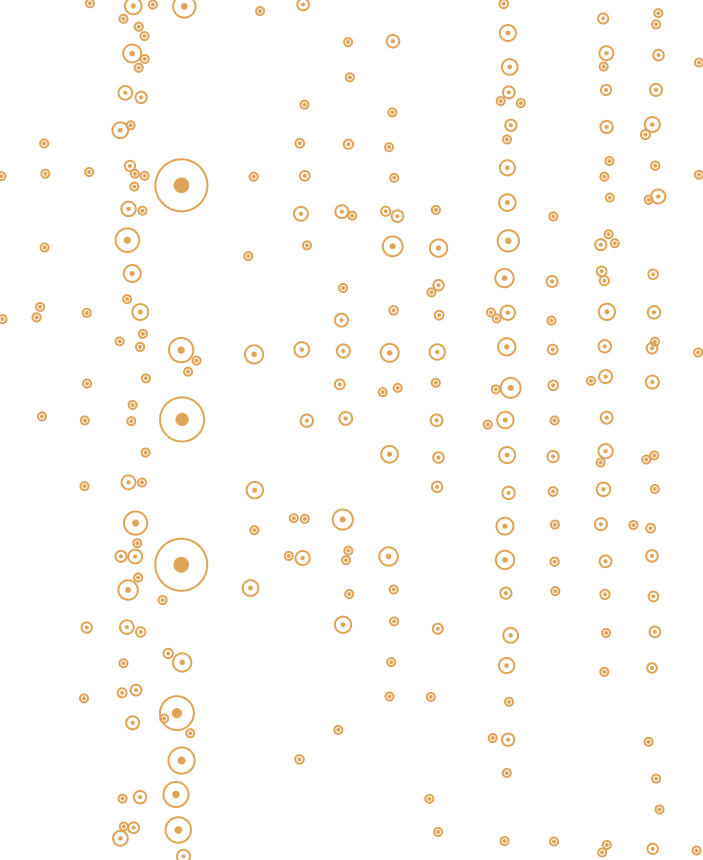

In [ ]:
from IPython.display import Image as IPyImage, display

display(IPyImage(filename="imagen_muestra.png", width=420))

### Probar el prototipo interactivo dentro del notebook

Incrustamos `conteo_vegetacion.html` en un `<iframe>` (vía *data URI*) para poder **arrastrar/soltar la imagen de muestra y mover los sliders directamente aquí**. Es exactamente el mismo archivo que abrirías con doble clic desde tu escritorio.

> ⚠️ Algunos entornos (sobre todo Google Colab, que ya sandboxea el output) pueden bloquear el *Web Worker* o la voz (`speechSynthesis`) dentro del iframe anidado. Si eso pasa, descarga `conteo_vegetacion.html` (queda guardado en la carpeta del notebook) y ábrelo con doble clic en tu navegador — ahí funciona al 100 %.

In [ ]:
import base64
from pathlib import Path
from IPython.display import HTML, display

html_bytes = Path("conteo_vegetacion.html").read_bytes()
html_b64 = base64.b64encode(html_bytes).decode("ascii")

iframe = f'''
<iframe src="data:text/html;base64,{html_b64}"
        style="width:100%; height:900px; border:1px solid #ccc; border-radius:8px;">
</iframe>
'''
display(HTML(iframe))
print("Tip: arrastra 'imagen_muestra.png' (o cualquier foto con vegetación) dentro del recuadro de arriba.")

Tip: arrastra 'imagen_muestra.png' (o cualquier foto con vegetación) dentro del recuadro de arriba.


## Fase 2 — `tile_pipeline.py`: preparación de tiles para etiquetado

Corta fotos grandes de dron en *tiles* (recortes) más pequeños para que cada planta ocupe suficientes píxeles al etiquetar en Roboflow/CVAT, y descarta automáticamente los tiles "vacíos" (puro suelo uniforme).

Como no tenemos fotos reales de dron a la mano, simulamos un **vuelo** (`ParcelaDemo_2026-09-26_emergencia`) reutilizando la imagen de muestra varias veces con nombres tipo `DJI_000X.JPG` — exactamente la estructura de carpetas que el script espera.

In [ ]:
import shutil
from pathlib import Path

flight_name = "ParcelaDemo_2026-09-26_emergencia"
fotos_dir = Path("fotos_dron") / flight_name
fotos_dir.mkdir(parents=True, exist_ok=True)

for i in range(1, 4):
    shutil.copy("imagen_muestra.png", fotos_dir / f"DJI_{i:04d}.JPG")

print("Fotos de vuelo simuladas:")
for f in sorted(fotos_dir.iterdir()):
    print(" -", f)

Fotos de vuelo simuladas:
 - fotos_dron/ParcelaDemo_2026-09-26_emergencia/DJI_0001.JPG
 - fotos_dron/ParcelaDemo_2026-09-26_emergencia/DJI_0002.JPG
 - fotos_dron/ParcelaDemo_2026-09-26_emergencia/DJI_0003.JPG


In [ ]:
!python3 tile_pipeline.py --input ./fotos_dron --output ./tiles \
    --tile-size 300 --overlap 0.15 --min-pixels 40

Vuelos/carpetas encontrados: 1
  ParcelaDemo_2026-09-26_emergencia: 36 tiles guardados, 0 descartados por parecer suelo vacio

Listo. 36 tiles generados en total.
Manifest guardado en: tiles/manifest.csv

Siguiente paso: sube la carpeta de tiles (por vuelo) a Roboflow o CVAT para etiquetar.


In [ ]:
import pandas as pd

manifest = pd.read_csv("tiles/manifest.csv")
print(f"{len(manifest)} tiles generados en el manifest.")
manifest.head(10)

36 tiles generados en el manifest.


,vuelo,imagen_origen,tile,x_offset,y_offset,tile_w,tile_h,imagen_ancho,imagen_alto
0,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00000_y00000.jpg,0,0,300,300,703,860
1,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00255_y00000.jpg,255,0,300,300,703,860
2,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00403_y00000.jpg,403,0,300,300,703,860
3,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00000_y00255.jpg,0,255,300,300,703,860
4,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00255_y00255.jpg,255,255,300,300,703,860
5,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00403_y00255.jpg,403,255,300,300,703,860
6,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00000_y00510.jpg,0,510,300,300,703,860
7,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00255_y00510.jpg,255,510,300,300,703,860
8,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00403_y00510.jpg,403,510,300,300,703,860
9,ParcelaDemo_2026-09-26_emergencia,DJI_0001.JPG,DJI_0001_x00000_y00560.jpg,0,560,300,300,703,860


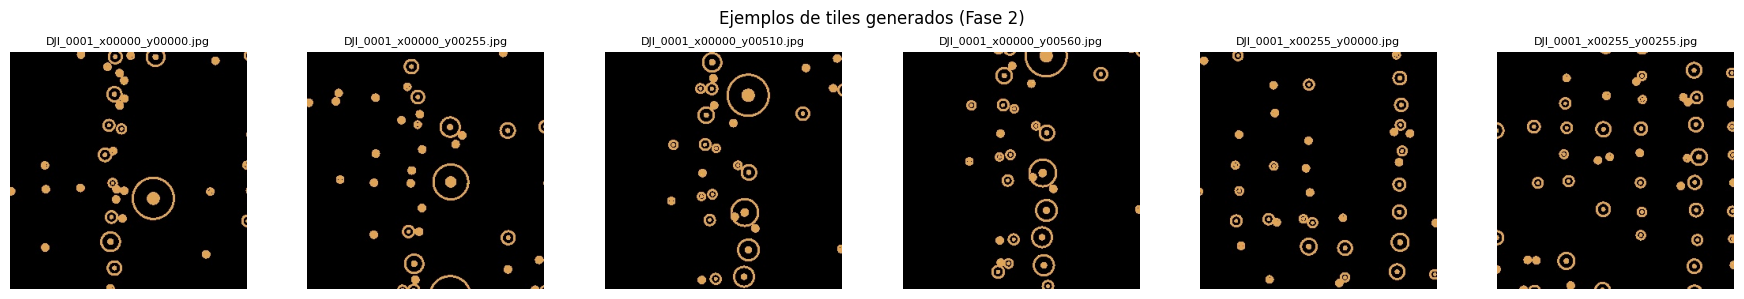

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

tiles_flight_dir = Path("tiles") / flight_name
tile_files = sorted(tiles_flight_dir.glob("*.jpg"))[:6]

fig, axes = plt.subplots(1, len(tile_files), figsize=(3 * len(tile_files), 3))
if len(tile_files) == 1:
    axes = [axes]
for ax, tile_path in zip(axes, tile_files):
    ax.imshow(Image.open(tile_path))
    ax.set_title(tile_path.name, fontsize=8)
    ax.axis("off")
plt.suptitle("Ejemplos de tiles generados (Fase 2)")
plt.tight_layout()
plt.show()

## Fase 2–3 · Etiquetado — `convert_polygon_to_bbox.py`

Cuando se etiqueta en **Roboflow** con polígonos y se exporta en formato `yolov8`, cada sidecar `.txt` trae líneas `clase x1 y1 x2 y2 ...` (polígono) en vez del formato `clase cx cy w h` (caja) que consumen `prepare_dataset.py` e `infer.py`. Este script:

1. Reconstruye el nombre original del tile a partir del renombrado que aplica Roboflow (`<tile>_jpg.rf.<hash>.jpg`).
2. Convierte cada polígono a su *bounding box* (mínimos/máximos de x e y).
3. Es *validate-then-write*: si cualquier etiqueta está mal formada, no escribe nada.

Simulamos un mini-export de Roboflow con un tile y un polígono de ejemplo:

In [ ]:
export_dir = Path("roboflow_export_demo/train")
(export_dir / "images").mkdir(parents=True, exist_ok=True)
(export_dir / "labels").mkdir(parents=True, exist_ok=True)

demo_tile = tile_files[0]
roboflow_name = f"{demo_tile.stem}_jpg.rf.abc123hash"
shutil.copy(demo_tile, export_dir / "images" / f"{roboflow_name}.jpg")

# Polígono de ejemplo (clase 0, 4 vértices) simulando una planta etiquetada a mano.
polygon_line = "0 0.30 0.30 0.55 0.28 0.58 0.55 0.32 0.57"
(export_dir / "labels" / f"{roboflow_name}.txt").write_text(polygon_line + "\n")

print("Export simulado de Roboflow:")
for f in sorted(export_dir.rglob("*")):
    if f.is_file():
        print(" -", f)

Export simulado de Roboflow:
 - roboflow_export_demo/train/images/DJI_0001_x00000_y00000_jpg.rf.abc123hash.jpg
 - roboflow_export_demo/train/labels/DJI_0001_x00000_y00000_jpg.rf.abc123hash.txt


In [ ]:
!python3 convert_polygon_to_bbox.py \
    --export roboflow_export_demo/train \
    --output labels_src_demo/$flight_name

DJI_0001_x00000_y00000: 1 cajas

Listo. 1 tiles, 1 cajas en total -> labels_src_demo/ParcelaDemo_2026-09-26_emergencia


In [ ]:
bbox_file = next(Path("labels_src_demo").rglob("*.txt"))
print("Etiqueta convertida a caja YOLO:")
print(" ", bbox_file, "->", bbox_file.read_text().strip())

Etiqueta convertida a caja YOLO:
  labels_src_demo/ParcelaDemo_2026-09-26_emergencia/DJI_0001_x00000_y00000.txt -> 0 0.44000000 0.42500000 0.28000000 0.29000000


## Fase 2–3 · `prepare_dataset.py`: armar el dataset YOLO

Toma el `manifest.csv` de `tile_pipeline.py` más una carpeta de *tiles etiquetados* (imagen + `.txt` opcional por tile) y escribe la estructura estándar YOLO:

```
dataset/
    images/{train,valid}/
    labels/{train,valid}/
    data.yaml
```

El split train/valid es **por vuelo** (para que los tiles de un mismo vuelo no se filtren entre train y valid) y usa una semilla fija (reproducible). Un tile sin `.txt` se vuelve una muestra de **fondo** (imagen sin etiqueta), no un error.

Para la demo, copiamos todos los tiles generados en la Fase 2 a una carpeta `labels_src/` (simulando "ya los etiqueté en Roboflow/CVAT") y le agregamos una etiqueta de caja a un par de tiles; el resto quedan como fondo.

In [ ]:
labels_src = Path("labels_src") / flight_name
labels_src.mkdir(parents=True, exist_ok=True)

# Copiamos TODOS los tiles del vuelo (prepare_dataset.py exige que cada tile
# del manifest exista en --labels, tenga o no etiqueta).
all_tiles = sorted(tiles_flight_dir.glob("*.jpg"))
for t in all_tiles:
    shutil.copy(t, labels_src / t.name)

# Etiquetamos "a mano" un par de tiles con una caja de ejemplo (clase 0 = plant).
dummy_box = "0 0.500000 0.500000 0.300000 0.300000\n"
labeled_count = 0
for t in all_tiles[:2]:
    (labels_src / t.with_suffix(".txt").name).write_text(dummy_box)
    labeled_count += 1

print(f"{len(all_tiles)} tiles copiados a labels_src/, {labeled_count} con etiqueta de ejemplo, "
      f"{len(all_tiles) - labeled_count} quedarán como fondo.")

36 tiles copiados a labels_src/, 2 con etiqueta de ejemplo, 34 quedarán como fondo.


In [ ]:
!python3 prepare_dataset.py \
    --manifest tiles/manifest.csv \
    --labels labels_src \
    --output dataset \
    --valid-ratio 0.2 \
    --seed 42

Dataset ready: 29 train / 7 valid images across 1 flights (34 background, image-only).


In [ ]:
print((Path("dataset") / "data.yaml").read_text())

print("\nEstructura generada:")
for p in sorted(Path("dataset").rglob("*")):
    if p.is_file():
        print(" -", p)

path: dataset
train: images/train
val: images/valid
names:
- plant


Estructura generada:
 - dataset/data.yaml
 - dataset/images/train/DJI_0001_x00000_y00000.jpg
 - dataset/images/train/DJI_0001_x00000_y00255.jpg
 - dataset/images/train/DJI_0001_x00000_y00510.jpg
 - dataset/images/train/DJI_0001_x00000_y00560.jpg
 - dataset/images/train/DJI_0001_x00255_y00000.jpg
 - dataset/images/train/DJI_0001_x00255_y00510.jpg
 - dataset/images/train/DJI_0001_x00255_y00560.jpg
 - dataset/images/train/DJI_0001_x00403_y00000.jpg
 - dataset/images/train/DJI_0001_x00403_y00510.jpg
 - dataset/images/train/DJI_0001_x00403_y00560.jpg
 - dataset/images/train/DJI_0002_x00000_y00255.jpg
 - dataset/images/train/DJI_0002_x00000_y00510.jpg
 - dataset/images/train/DJI_0002_x00000_y00560.jpg
 - dataset/images/train/DJI_0002_x00255_y00000.jpg
 - dataset/images/train/DJI_0002_x00255_y00255.jpg
 - dataset/images/train/DJI_0002_x00255_y00510.jpg
 - dataset/images/train/DJI_0002_x00403_y00000.jpg
 - dataset/images/trai

## Fase 3 · `train.py`: entrenar el modelo YOLO26

Entrena un modelo de detección sobre el `dataset/data.yaml` generado en el paso anterior, usando `ultralytics`. El import de `ultralytics` es **perezoso** (dentro de la función), así que `--help` y los tests corren sin instalar el runtime pesado.

```
python3 train.py --data dataset/data.yaml --weights yolo26n.pt --epochs 100 --imgsz 640 --batch 8
```

> ⚠️ **Paso pesado y opcional.** Instala `ultralytics` (arrastra `torch`/`torchvision`) y entrena de verdad, aunque sea con pocas épocas. Con un dataset de juguete de un par de imágenes (como el de este notebook) el modelo **no va a generalizar** — igual que documenta el proyecto sobre el piloto real con 6 tiles (mAP50 ≈ 0, esperado). El objetivo aquí es solo confirmar que el *pipeline* corre de punta a punta, no obtener un buen modelo.
>
> Cambia `RUN_TRAINING = True` en la siguiente celda si quieres ejecutarlo (puede tardar varios minutos, incluso en CPU con pocas épocas).

In [ ]:
RUN_TRAINING = False  # <-- cámbialo a True para entrenar de verdad (lento, instala ultralytics/torch)

if RUN_TRAINING:
    %pip install -q "ultralytics==8.4.161" "opencv-python==5.0.0.93"
    print("ultralytics instalado.")
else:
    print("RUN_TRAINING=False: se omite la instalación pesada y el entrenamiento real.")
    print("Puedes ver los argumentos disponibles del script sin instalar nada extra:")

RUN_TRAINING=False: se omite la instalación pesada y el entrenamiento real.
Puedes ver los argumentos disponibles del script sin instalar nada extra:


In [ ]:
!python3 train.py --help

usage: train.py [-h] --data DATA [--weights WEIGHTS] [--epochs EPOCHS]
                [--imgsz IMGSZ] [--batch BATCH] [--project PROJECT]
                [--resume RESUME]

Train a YOLO26 detection model on a prepare_dataset.py dataset (FR-5).

options:
  -h, --help         show this help message and exit
  --data DATA        path to the data.yaml prepared by prepare_dataset.py
  --weights WEIGHTS  pretrained weights (.pt) or model yaml (default:
                     yolo26n.pt)
  --epochs EPOCHS    training epochs (default: 100)
  --imgsz IMGSZ      training image size (default: 640)
  --batch BATCH      batch size (default: 8)
  --project PROJECT  root for training artifacts under runs/ (default: runs/)
  --resume RESUME    path to a last.pt checkpoint to continue from (default:
                     none)


In [ ]:
if RUN_TRAINING:
    !python3 train.py \
        --data dataset/data.yaml \
        --weights yolo26n.pt \
        --epochs 3 \
        --imgsz 320 \
        --batch 2 \
        --project runs/demo
else:
    print("Entrenamiento omitido (RUN_TRAINING=False).")

Entrenamiento omitido (RUN_TRAINING=False).


In [ ]:
from pathlib import Path

best_weights = None
if RUN_TRAINING:
    candidates = sorted(Path("runs/demo").rglob("best.pt"))
    if candidates:
        best_weights = candidates[-1]
        print("Pesos entrenados encontrados en:", best_weights)
    else:
        print("No se encontró best.pt (revisa el log de entrenamiento de arriba).")
else:
    print("Sin pesos entrenados propios: la siguiente celda de inferencia usará solo el --help como demostración.")

Sin pesos entrenados propios: la siguiente celda de inferencia usará solo el --help como demostración.


## Fase 3 · `infer.py`: conteo con el modelo entrenado

CLI determinista de conteo: para cada foto agrupa sus tiles, corre el modelo, filtra por confianza (`--conf`), proyecta cada caja a coordenadas de la foto completa y elimina duplicados entre tiles con **NMS por IoU global** (`--iou`). Escribe un CSV solo si **todas** las fotos se procesaron sin error (*validate-then-write*, escritura atómica).

```
python3 infer.py --weights best.pt --input ./tiles --output conteo.csv --summary --verbose
```

Acepta tanto un directorio (`manifest.csv` + tiles, con deduplicación entre tiles) como una foto suelta (sin deduplicación).

In [ ]:
!python3 infer.py --help

usage: infer.py [-h] --weights PATH --input PATH --output CSV [--conf F]
                [--iou F] [--summary] [--verbose]

Count plants in drone photos from YOLO detections over tile_pipeline.py tiles
(FR-1).

options:
  -h, --help      show this help message and exit
  --weights PATH  trained YOLO weights (.pt); must exist and be readable (else
                  exit 2)
  --input PATH    single photo (JPEG/PNG/TIF) OR directory containing
                  manifest.csv + tiles/
  --output CSV    CSV path; written only after ALL photos succeed (NFR-6)
  --conf F        minimum detection confidence, strictly between 0 and 1
                  (default 0.25)
  --iou F         global NMS IoU threshold, strictly between 0 and 1 (default
                  0.5)
  --summary       print per-flight totals to stdout
  --verbose       print per-photo progress lines


In [ ]:
if best_weights is not None:
    !python3 infer.py \
        --weights {best_weights} \
        --input ./tiles \
        --output ./conteo.csv \
        --summary --verbose
    import pandas as pd
    display(pd.read_csv("conteo.csv"))
else:
    print(
        "No hay un modelo entrenado en este notebook (RUN_TRAINING=False o el "
        "entrenamiento no produjo best.pt).\n"
        "Con un archivo de pesos real (.pt) entrenado sobre datos etiquetados de "
        "verdad, correrías exactamente el comando de arriba para obtener conteo.csv."
    )

No hay un modelo entrenado en este notebook (RUN_TRAINING=False o el entrenamiento no produjo best.pt).
Con un archivo de pesos real (.pt) entrenado sobre datos etiquetados de verdad, correrías exactamente el comando de arriba para obtener conteo.csv.


## Tests automatizados (opcional)

El proyecto trae dos suites de tests que puedes correr en tu propio entorno (fuera de este notebook si `node`/`npm` no están disponibles aquí):

- **Python** (`pytest`): cubre `prepare_dataset.py`, `train.py`, `infer.py`, `convert_polygon_to_bbox.py`.
  ```bash
  pip install -r requirements.txt
  pytest
  ```
- **JavaScript** (`node --test`, sin dependencias): cubre la lógica de detección (`computeDetection`) y el resumen hablado (`buildResultSpeech`) extraídos de `conteo_vegetacion.html`.
  ```bash
  npm test
  ```

Si `pytest` está disponible en este entorno, puedes intentar correr la suite de Python directamente (puede fallar si falta `ultralytics`/`node`, que son dependencias pesadas u opcionales de algunos tests):

In [ ]:
import shutil as _shutil

if _shutil.which("pytest"):
    !pytest -q --no-header || true
else:
    print("pytest no está instalado en este entorno. Instálalo con:\n  pip install pytest pyyaml")


no tests ran in 0.03s


## Resumen y próximos pasos

Este notebook demostró el pipeline completo con datos sintéticos:

1. ✅ **Fase 1** — prototipo interactivo por color (Excess Green Index), corriendo 100% en el navegador dentro del notebook.
2. ✅ **Fase 2** — `tile_pipeline.py` cortó la foto de muestra en tiles y generó `manifest.csv`.
3. ✅ **Fase 2–3** — `convert_polygon_to_bbox.py` convirtió una etiqueta de polígono a caja, y `prepare_dataset.py` armó un dataset YOLO (`images/`, `labels/`, `data.yaml`) con split por vuelo.
4. ✅ **Fase 3** — `train.py` (opcional) y `infer.py` mostraron cómo se entrena y cómo se cuenta con un modelo real.

### Para usar esto con datos reales

1. Reemplaza `fotos_dron/<vuelo>/` con tus fotos reales de dron (una subcarpeta por vuelo: parcela + fecha + etapa).
2. Corre `tile_pipeline.py` con los parámetros reales (`--tile-size`, `--overlap`, `--min-pixels`).
3. Sube los tiles a **Roboflow** o **CVAT** y etiqueta las plantas (clase `plant`).
4. Si etiquetaste con polígonos en Roboflow, conviértelos con `convert_polygon_to_bbox.py`.
5. Arma el dataset con `prepare_dataset.py` y entrena con `train.py` (idealmente con **muchas más imágenes** que las de este demo — el modelo piloto del proyecto con 6 tiles no generalizó, ver `REPORTE_FASES.md` / Módulo 5 del `README.md`).
6. Cuenta plantas en fotos nuevas con `infer.py`.

### Roadmap pendiente (según el `README.md` del proyecto)

- Etiquetar un **dataset grande** de fotos reales para que el modelo generalice (Módulo 5.11).
- Optimización opcional: `OffscreenCanvas` dentro del *worker* del prototipo HTML para evitar la transferencia de `getImageData` en el hilo principal.
